# Análisis Univariado

Se realiza un análisis exploratorio de cada variable de manera independiente, examinando sus distribuciones, frecuencias y principales estadísticos descriptivos, con el objetivo de comprender el comportamiento individual de las características del dataset e identificar patrones, valores atípicos y particularidades relevantes para las etapas posteriores del estudio.

## Carga de Librerías

Se importan las librerías necesarias para el análisis avanzado de los datos. Se emplean `pandas` y `numpy` para la manipulación y cálculo de estadísticos; `matplotlib.pyplot`, `seaborn` y `plotly.graph_objects` para la generación de gráficos estáticos e interactivos; y `scikit_posthocs` para pruebas post-hoc en análisis no paramétricos. Adicionalmente, se incorporan `scipy.stats` para pruebas estadísticas complementarias y `statsmodels.stats.multicomp.pairwise_tukeyhsd` para análisis post-hoc paramétricos. Finalmente, se suprimen los mensajes de advertencia (`warnings`) con el fin de mantener una salida limpia y centrada en los resultados del análisis.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import scikit_posthocs as sp
import plotly.io as pio

from IPython.display import display
from IPython.display import HTML
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from matplotlib.colors import to_hex

In [2]:
pio.renderers.default = "notebook_connected"

## Carga del DataFrame

Se carga el archivo CSV que contiene los datos de comparendos electrónicos utilizando la función `read_csv` de la librería pandas, y se almacena en el DataFrame `df_comparendos_electronicos`.

In [3]:
df_comparendos_electronicos = pd.read_csv("C:/Users/david/Documents/seminario_investigativo/comparendos_electronicos.csv")

### Conversión de las Fechas a Formato datetime

Se convierte la columna `fecha_comparendo` al tipo `datetime` utilizando el formato especificado (`'%Y %b %d %I:%M:%S %p'`), normalizando la hora a medianoche con el método `.dt.normalize()` para eliminar la información horaria y trabajar únicamente con fechas, dado que todos los registros contienen la hora de 12:00:00 AM. Posteriormente, se imprime el tipo de dato resultante para verificar la correcta conversión.

In [4]:
df_comparendos_electronicos['fecha_comparendo'] = pd.to_datetime(df_comparendos_electronicos['fecha_comparendo'], format='%Y %b %d %I:%M:%S %p').dt.normalize()

print(df_comparendos_electronicos['fecha_comparendo'].dtype)

datetime64[ns]


### Corrección de Valores Nulos

Se rellenan los valores nulos de la columna `DESC_INFRACCION` con la descripción correspondiente al código C14, obtenida del sitio web oficial del Tránsito del Atlántico. Según esta fuente, la infracción C14 corresponde a **"Transitar por sitios restringidos o en horas prohibidas por la autoridad competente"**. Esta corrección se aplica exclusivamente a los 564 registros que presentaban valores nulos, asociados a las nuevas cámaras tipo Carril Bus implementadas en Barranquilla a partir del 17 de octubre de 2025.

**Fuente:** https://transitodelatlantico.gov.co/valor-de-multas-de-transito/

In [5]:
df_comparendos_electronicos['DESC_INFRACCION'] = df_comparendos_electronicos['DESC_INFRACCION'].fillna("Transitar por sitios restringidos o en horas prohibidas por la autoridad competente")  

print(f"Total de valores nulos en el DataFrame: {df_comparendos_electronicos.isnull().sum().sum()}")

Total de valores nulos en el DataFrame: 0


## Distribución de Frecuencias de la Variable `CANTIDAD_INFRACCIONES`

Se presenta la tabla de frecuencias de la variable `CANTIDAD_INFRACCIONES`, mostrando para cada valor la cantidad de registros que lo presentan, el porcentaje que representa sobre el total de filas y el porcentaje acumulado. Esta visualización permite comprender la concentración de los valores, identificar los rangos más comunes de agrupación de infracciones y evaluar la contribución de cada categoría a la estructura general de la base de datos.

In [6]:
frecuencias = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].value_counts().sort_index().rename_axis('Cantidad').reset_index(name='Frecuencia')

frecuencias.columns = ['Cantidad', 'Frecuencia']
frecuencias['Porcentaje'] = frecuencias['Frecuencia'] / len(df_comparendos_electronicos) * 100
frecuencias['Porcentaje Acumulado'] = frecuencias['Porcentaje'].cumsum()

frecuencias_display = frecuencias.copy()
frecuencias_display['Cantidad'] = frecuencias_display['Cantidad'].apply(lambda x: f"{int(x)}")
frecuencias_display['Frecuencia'] = frecuencias_display['Frecuencia'].apply(lambda x: f"{int(x)}")
frecuencias_display['Porcentaje'] = frecuencias_display['Porcentaje'].round(8)
frecuencias_display['Porcentaje Acumulado'] = frecuencias_display['Porcentaje Acumulado'].round(8)


pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_colwidth', None) 
display(frecuencias_display.T)
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
Cantidad,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,45,46,47,48,49,50,52,53,55,56,57,59,61,63,64,73,76,78,81,166,172
Frecuencia,232877,52089,21627,11473,6925,4343,2896,2001,1419,913,709,518,400,267,220,160,137,94,88,59,46,42,39,35,32,23,21,14,12,17,14,14,6,6,5,5,8,7,6,5,5,1,4,2,2,5,3,1,3,2,2,1,1,2,1,1,1,1,1,1,1,1,1,1
Porcentaje,68.57068,15.337617,6.368075,3.378227,2.039068,1.278797,0.852728,0.589195,0.417825,0.268833,0.208765,0.152525,0.11778,0.078618,0.064779,0.047112,0.04034,0.027678,0.025912,0.017373,0.013545,0.012367,0.011484,0.010306,0.009422,0.006772,0.006183,0.004122,0.003533,0.005006,0.004122,0.004122,0.001767,0.001767,0.001472,0.001472,0.002356,0.002061,0.001767,0.001472,0.001472,0.000294,0.001178,0.000589,0.000589,0.001472,0.000883,0.000294,0.000883,0.000589,0.000589,0.000294,0.000294,0.000589,0.000294,0.000294,0.000294,0.000294,0.000294,0.000294,0.000294,0.000294,0.000294,0.000294
Porcentaje Acumulado,68.57068,83.908296,90.276371,93.654598,95.693666,96.972463,97.825191,98.414386,98.832211,99.101044,99.309809,99.462334,99.580114,99.658732,99.723511,99.770623,99.810963,99.838641,99.864553,99.881925,99.89547,99.907837,99.919321,99.929626,99.939049,99.945821,99.952005,99.956127,99.95966,99.964666,99.968788,99.972911,99.974677,99.976444,99.977916,99.979388,99.981744,99.983805,99.985572,99.987044,99.988516,99.988811,99.989989,99.990578,99.991166,99.992639,99.993522,99.993817,99.9947,99.995289,99.995878,99.996172,99.996467,99.997056,99.99735,99.997644,99.997939,99.998233,99.998528,99.998822,99.999117,99.999411,99.999706,100.0


Los resultados muestran la distribución detallada de los valores de `CANTIDAD_INFRACCIONES`, que representa el número de infracciones agrupadas en cada registro; cuando varias ocurren con características idénticas (misma fecha, misma cámara, mismo vehículo, etc.) actuando como un mecanismo de simplificación en la estructura de la base de datos. A continuación, se presentan los hallazgos más relevantes:

**Concentración mayoritaria en valores bajos:**
- **Valor 1**: Representa el **68.57%** de los registros (232,877 registros). Esto indica que la mayoría de las filas corresponden a agrupaciones de una sola infracción, es decir, no hubo consolidación de múltiples eventos con características idénticas.
- **Valor 2**: Acumula el **15.34%** de los registros (52,089 registros).
- **Valor 3**: Representa el **6.37%** (21,627 registros).

Entre los valores 1, 2 y 3 se concentra el **90.28%** del total de registros, lo que confirma que la gran mayoría de las agrupaciones son pequeñas (entre 1 y 3 infracciones por registro).


**Valores altos y extremos:**
- Se observan valores esporádicos desde 25 hasta 172, cada uno con porcentajes inferiores al **0.010%**.
- Destacan los valores extremos:
  - **166 infracciones**: 1 registro (0.000294%)
  - **172 infracciones**: 1 registro (0.000294%)

Estos valores extremos representan casos muy particulares donde se consolidaron decenas o centenas de infracciones con características idénticas en un solo registro.

## Estadísticos Descriptivos de la Variable `CANTIDAD_INFRACCIONES`

Se presentan los principales estadísticos descriptivos de la variable `CANTIDAD_INFRACCIONES`, incluyendo el conteo, media, desviación estándar, valores mínimo y máximo, así como los cuartiles (25%, 50% y 75%). Estos resúmenes numéricos permiten caracterizar la tendencia central, la dispersión y la forma de distribución de la cantidad de infracciones por comparendo.

In [7]:
display(df_comparendos_electronicos["CANTIDAD_INFRACCIONES"].describe().round(2).to_frame().T)

,count,mean,std,min,25%,50%,75%,max
CANTIDAD_INFRACCIONES,339616.0,1.81,2.06,1.0,1.0,1.0,2.0,172.0


**Medidas de tendencia central y dispersión:**
- **Media (1.81)**: En promedio, cada registro contiene aproximadamente 2 infracciones agrupadas.
- **Mediana (1)**: El 50% de los registros corresponde a un único evento de infracción sin agrupación.
- **Desviación estándar (2.06)**: Existe una dispersión considerable, indicando que hay registros con valores altos que representan agrupaciones de múltiples casos.


**Distribución por cuartiles:**
- **25% (1)**: Indica que el 25% de los registros tiene un valor menor o igual a 1, Como el valor mínimo es 1, esto significa que al menos el 25% de los registros son exactamente 1.
- **50% (1)**: La mediana indica que el 50% de los registros tiene un valor igual a 1, lo que confirma que la mitad de los registros corresponde a casos individuales sin agrupación.
- **75% (2)**: Indica que el 75% de los registros tiene un valor menor o igual a 2, es decir, la mayoría de los registros no supera las 2 infracciones agrupadas.


**Hallazgos:**
- **Asimetría positiva**: La media (1.81) es mayor que la mediana (1), lo que indica que la distribución está sesgada hacia la derecha debido a la presencia de registros con agrupaciones altas.
- **Concentración mayoritaria**: El 75% de los registros tiene 2 o menos infracciones agrupadas, lo que indica que la mayoría de las agrupaciones son pequeñas o inexistentes.
- **Función de la variable**: Esta actúa como un factor de agregación que permite almacenar múltiples infracciones idénticas en un solo registro, optimizando la estructura de la base de datos. Por esta razón, para obtener el número total de comparendos electrónicos se debe utilizar `CANTIDAD_INFRACCIONES.sum()` en lugar del conteo de filas.

## Análisis Gráfico de la Distribución de la Variable `CANTIDAD_INFRACCIONES`

Se presenta un análisis visual de la variable `CANTIDAD_INFRACCIONES` a través de un histograma y un diagrama de caja (boxplot), complementados con medidas de forma y dispersión como la asimetría (skewness), kurtosis y coeficiente de variación. Para la construcción del histograma, se determina el número de intervalos (bins) utilizando la **regla de Sturges**. Esta regla permite definir una cantidad adecuada de bins para visualizar la forma de la distribución sin perder detalle. Estas visualizaciones permiten apreciar la forma de la distribución, identificar la presencia de valores extremos y evaluar la relación entre la media y la mediana, facilitando la comprensión del comportamiento de la variable como factor de agrupación de infracciones.

- **Asimetría**: Determina si una distribución está sesgados hacia la izquierda (asimetría negativa) o hacia la derecha (asimetría positiva) en relación con la media.
    - **skew = 0**: Distribución simétrica; valores aceptables entre $(-1,1)$.
    - **skew > 0**: Mayor peso en la cola izquierda de la distribución (sesgo positivo).
    - **skew < 0**: Mayor peso en la cola derecha de la distribución (sesgo negativo).

- **Kurtosis**: Determina si una distribución tiene colas gruesas con respecto a la distribución normal. Proporciona información sobre la forma de una distribución de frecuencias.
    - **kurtosis = 3**: se denomina mesocúrtica (distribución normal).
    - **kurtosis < 3**: se denomina platicúrtica (distribución con colas menos gruesas que la normal).
    - **kurtosis > 3**: se denomina leptocúrtica (distribución con colas más gruesas que la normal) y significa que trata de producir más valores atípicos que la distribución normal.

- **Coeficiente de Variación**: Es una medida estadística que se utiliza para evaluar la variabilidad relativa de una muestra en relación con su media. Se calcula como la desviación estándar de los datos dividida por la media, y se expresa como un porcentaje multiplicado por 100 para facilitar su interpretación.

- **Regla de Sturges**: $log₂(n) + 1$; donde $n$ representa el número total de observaciones.

Bins utilizados (Sturges): 19
Skew: 9.6278
Kurtosis: 348.0843
Coeficiente de Variación: 113.9932 %


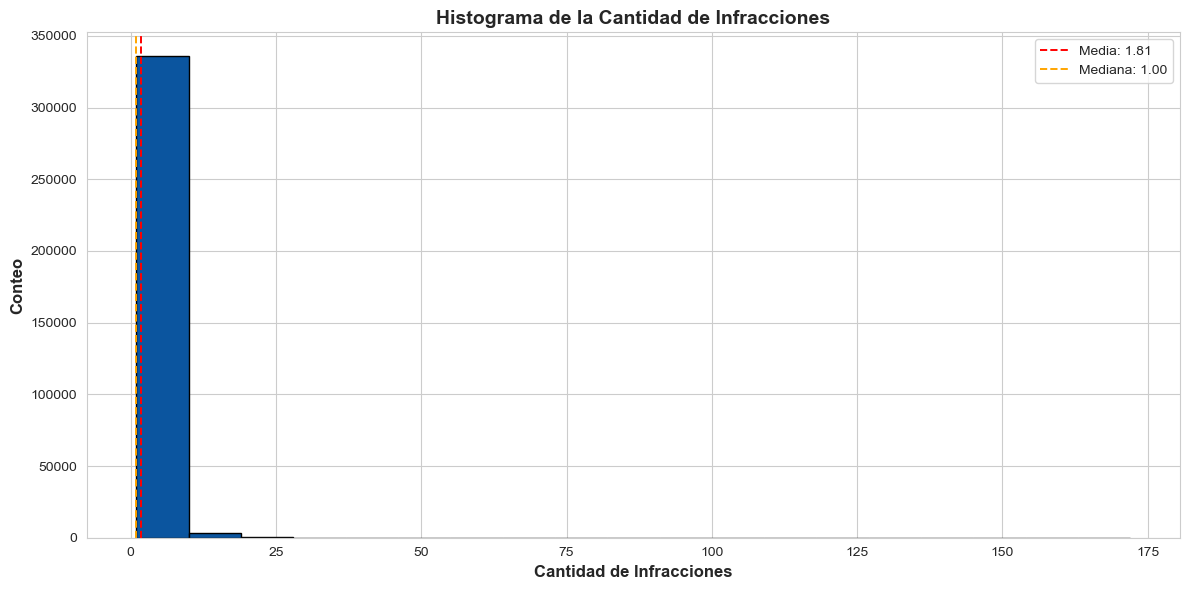

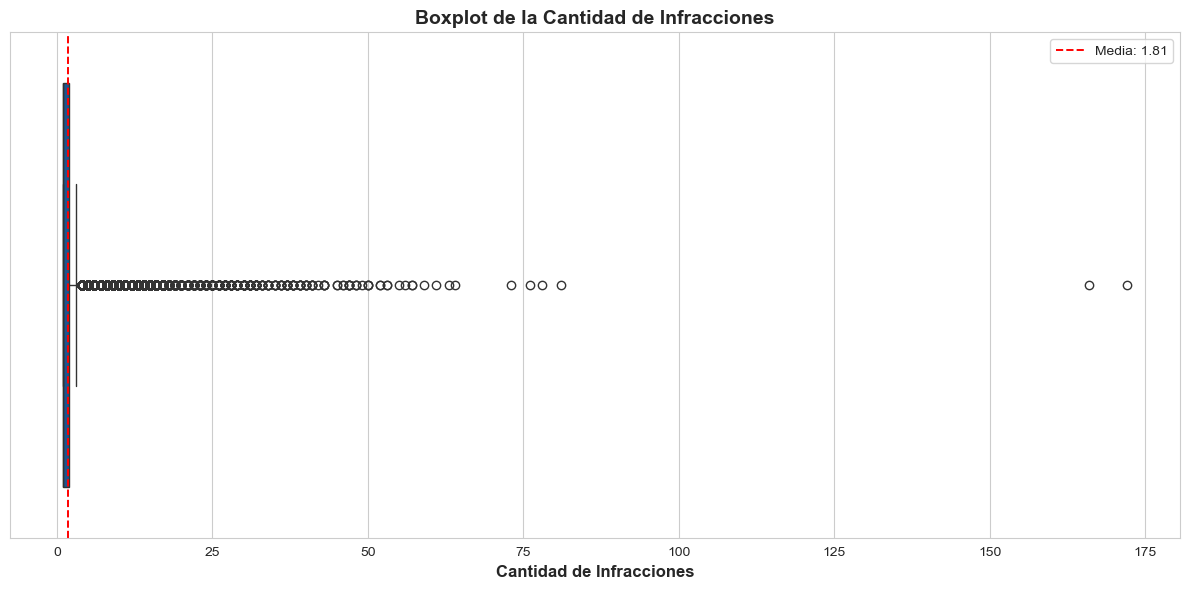

In [8]:
sns.set_style("whitegrid")

colors = sns.color_palette("Blues")
colors = colors[::-1] 

skew = round(df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].skew(), 4)
kurtosis = round(df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].kurtosis(), 4)
coef_variacion = (df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].std() / df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].mean()) * 100
media = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].mean()
mediana = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].median()

n = len(df_comparendos_electronicos['CANTIDAD_INFRACCIONES'])
bins_sturges = int(np.log2(n) + 1)

print(f"Bins utilizados (Sturges): {bins_sturges}")
print(f"Skew: {skew}")
print(f"Kurtosis: {kurtosis}")
print(f"Coeficiente de Variación: {round(coef_variacion, 4)} %")

plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(df_comparendos_electronicos['CANTIDAD_INFRACCIONES'], edgecolor="black", color=colors[0], bins=bins_sturges)
plt.axvline(media, color='red', linestyle='--', linewidth=1.4, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='orange', linestyle='--', linewidth=1.4, label=f'Mediana: {mediana:.2f}')
plt.title('Histograma de la Cantidad de Infracciones', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Infracciones', fontsize=12, fontweight='bold')
plt.ylabel('Conteo', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x=df_comparendos_electronicos['CANTIDAD_INFRACCIONES'], color=colors[0])
plt.axvline(media, color='red', linestyle='--', linewidth=1.4, label=f'Media: {media:.2f}')
plt.title('Boxplot de la Cantidad de Infracciones', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Infracciones', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

- **Asimetría (Skewness = 9.6278)**: La asimetría positiva extremadamente alta (mucho mayor que 0) indica que la distribución presenta una **cola extremadamente larga hacia la derecha**. Esto significa que la gran mayoría de los registros se concentran en valores bajos (principalmente 1 y 2), mientras que existen pocos registros con valores muy altos (hasta 172) que extienden significativamente la cola derecha de la distribución.

- **Curtosis (Kurtosis = 348.0843)**: La curtosis extremadamente alta (muy superior a 3, que sería el valor de una distribución normal) indica una **distribución leptocúrtica con colas muy pesadas y un pico muy pronunciado**. Esto confirma que la distribución tiene una concentración inusualmente alta de valores alrededor de la moda (valor 1), junto con la presencia de valores atípicos extremos en la cola derecha que generan esta curtosis tan elevada.

- **Coeficiente de Variación = 113.9932%**: Un coeficiente de variación superior al 100% indica una **dispersión muy alta en relación con la media**. Lo que refleja la alta variabilidad relativa de los datos. Este resultado es coherente con la presencia de valores extremos que incrementan considerablemente la dispersión, a pesar de que la mayoría de los registros se concentran en valores bajos.

### Detección de Valores Atípicos Mediante el Método del Rango Intercuartil

Se identifican los valores atípicos (outliers) en la variable `CANTIDAD_INFRACCIONES` utilizando el método del rango intercuartil (IQR). Para ello, se calculan el primer cuartil (Q1), el tercer cuartil (Q3) y el rango intercuartil (IQR = Q3 - Q1). Se establecen como límites inferior y superior aquellos valores que se encuentran a 1.5 veces el IQR por debajo de Q1 o por encima de Q3. Los registros que superan estos límites son considerados outliers. Cabe aclarar que estos valores atípicos no serán eliminados, ya que corresponden a agrupaciones válidas de múltiples infracciones con características idénticas. El objetivo de esta detección es exclusivamente cuantificarlos y comprender su impacto en la distribución de la variable.

In [9]:
Q1 = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].quantile(0.25)
Q3 = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_comparendos_electronicos[(df_comparendos_electronicos['CANTIDAD_INFRACCIONES'] < limite_inferior) | (df_comparendos_electronicos['CANTIDAD_INFRACCIONES'] > limite_superior)]

print(f"Límite inferior: {limite_inferior.round(2)}")
print(f"Límite superior: {limite_superior.round(2)}")
print(f"Número de outliers: {len(outliers)}")
print(f"Porcentaje de outliers: {(len(outliers) / len(df_comparendos_electronicos) * 100):.5}%")

Límite inferior: -0.5
Límite superior: 3.5
Número de outliers: 33023
Porcentaje de outliers: 9.7236%


Dado que la variable `CANTIDAD_INFRACCIONES` solo toma valores enteros positivos (mínimo 1), el límite inferior no tiene relevancia práctica, ya que ningún valor válido puede estar por debajo de 1.

- **Outliers en este contexto**: Según el método IQR, cualquier registro con 4 o más infracciones agrupadas es considerado un valor atípico. Sin embargo, como se aclaró previamente, estos valores no representan errores ni inconsistencias, sino agrupaciones válidas de múltiples infracciones con características idénticas.

- **Proporción significativa de valores "atípicos"**: Con un 9.7% de registros en esta categoría, no se trata de casos aislados o excepcionales, sino de una porción considerable de la base de datos. Esto confirma que la consolidación de múltiples infracciones en un solo registro es un fenómeno recurrente, especialmente en valores de 4 a 24 infracciones.

## Análisis del Tipo de Cámara

Se examina la distribución de los comparendos electrónicos según el tipo de cámara utilizada para la detección de infracciones. Para ello, se agrupan los registros por la variable `Tipo Camara`, sumando la columna `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones por cada categoría. Se calculan los porcentajes de participación y se presentan los resultados mediante una tabla de frecuencias, un gráfico de barras y un gráfico circular que muestran las cantidades absolutas y la proporción relativa de cada tipo de cámara. Esta visualización permite identificar qué tecnologías de vigilancia contribuyen en mayor medida al total de comparendos electrónicos.

Distribución de Comparendos Electrónicos por Tipo de Cámara


,Tipo de Cámara,Comparendos,Porcentaje
0,Fijo,407659,66.35
1,Movil,204973,33.36
2,Carril Bus,1730,0.28


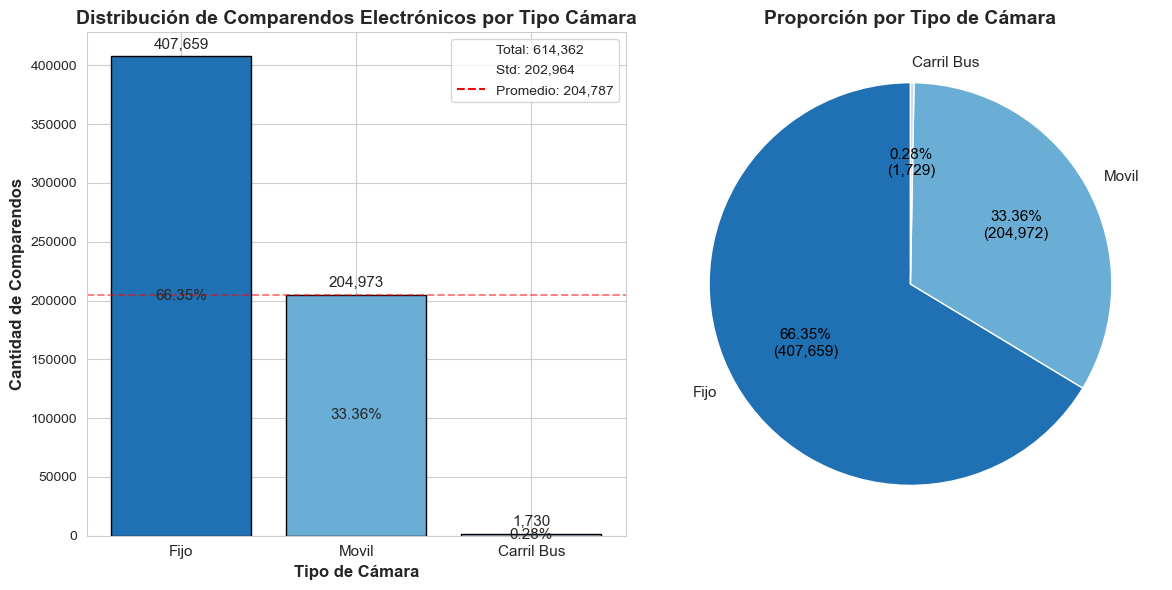

In [10]:
comparendos_por_camara = df_comparendos_electronicos.groupby('Tipo Camara')['CANTIDAD_INFRACCIONES'].sum().sort_values(ascending=False)
total_infracciones = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].sum()
porcentajes = (comparendos_por_camara / total_infracciones * 100).round(2)

desviacion_estandar = comparendos_por_camara.std()

df_grafico = pd.DataFrame({
    'Tipo de Cámara': comparendos_por_camara.index,
    'Comparendos': comparendos_por_camara.values,
    'Porcentaje': porcentajes.values
})

print("Distribución de Comparendos Electrónicos por Tipo de Cámara")
display(df_grafico)

display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.set_style("whitegrid")


colors = sns.color_palette("Blues", n_colors=len(df_grafico))
colors = colors[::-1] 

bars = axes[0].bar(range(len(df_grafico)), df_grafico['Comparendos'], color=colors, edgecolor='black', linewidth=1)
axes[0].set_title('Distribución de Comparendos Electrónicos por Tipo Cámara', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tipo de Cámara', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad de Comparendos', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(len(df_grafico)))
axes[0].set_xticklabels(df_grafico['Tipo de Cámara'], fontsize=11)

for i, (bar, conteo, porcentaje) in enumerate(zip(bars, df_grafico['Comparendos'], df_grafico['Porcentaje'])):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(df_grafico['Comparendos'])*0.01),
                 f'{int(conteo):,}', ha='center', va='bottom', fontsize=11)
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
                 f'{porcentaje}%', ha='center', va='center', fontsize=11)

axes[0].axhline(y=total_infracciones/len(df_grafico), color='red', linewidth=1.4, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper right', handles=[
    plt.Line2D([0], [0], color='white', label=f'Total: {int(total_infracciones):,}'),
    plt.Line2D([0], [0], color='white', label=f'Std: {int(desviacion_estandar):,}'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'Promedio: {int(total_infracciones/len(df_grafico)):,}')
])

wedges, texts, autotexts = axes[1].pie(df_grafico['Comparendos'], 
                                        labels=df_grafico['Tipo de Cámara'],
                                        autopct=lambda pct: f'{pct:.2f}%\n({int(pct/100*total_infracciones):,})',
                                        startangle=90,
                                        colors=colors,
                                        textprops={'fontsize': 11})
for autotext in autotexts:
    autotext.set_color('black')

axes[1].set_title('Proporción por Tipo de Cámara', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

- **Cámaras fijas (66.35%)**: Constituyen la categoría predominante, concentrando la mayoría del total de infracciones (407,659 eventos). Este tipo de cámara representa la principal fuente de detección de infracciones en la ciudad.

- **Cámaras móviles (33.36%)**: Representan aproximadamente un tercio del total de infracciones (204,973 eventos). Aunque su participación es menor que la de las cámaras fijas, sigue siendo una proporción significativa en el control de infracciones.

- **Cámaras carril bus (0.28%)**: Concentran la menor proporción, con solo 1,730 infracciones. Este bajo porcentaje se explica por su implementación reciente, a partir del **17 de octubre de 2025**, lo que limita su período de operación dentro del rango de fechas de la base de datos.

---

**Comparación con el promedio:**

- **Cámaras fijas**: Superan ampliamente el promedio (407,659 vs 204,787), casi el doble.
- **Cámaras móviles**: Se aproximan al promedio (204,973 vs 204,787), prácticamente iguales.
- **Cámaras carril bus**: Se encuentran muy por debajo del promedio (1,730 vs 204,787), debido a su reciente implementación.

**Nota**: La alta concentración en cámaras fijas sugiere que cualquier mejora o mantenimiento de esta infraestructura tendría un impacto significativo en la detección de infracciones.

## Análisis del Código de Infracción

Se examina la distribución de los comparendos electrónicos según el código de infracción, utilizando la suma ponderada de `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones por cada categoría. Se calculan los porcentajes de participación y se presentan los resultados mediante una tabla de frecuencias, acompañada de las descripciones correspondientes a cada código. Complementariamente, se visualiza la distribución a través de un gráfico de barras que muestra las cantidades absolutas y los porcentajes, permitiendo identificar qué tipos de infracción son más frecuentes en el sistema de comparendos electrónicos.

Distribución de Comparendos Electrónicos por Código de Infracción


,Código de Infracción,Comparendos,Porcentaje
0,C29,284755,46.35
1,C02,204975,33.36
2,C03,65230,10.62
3,D04,54303,8.84
4,C32,3369,0.55
5,C14,1730,0.28


Descripción de los Códigos de Infracción


,COD_INFRACCION,DESC_INFRACCION
0,C29,"Conducir un vehículo a velocidad superior a la máxima permitida, la cual deberá estar señalizada en forma sectorizada, la cual no podrá ser superior"
1,C02,Estacionar un vehículo en los sitios prohibidos
2,C03,"Bloquear una calzada o intersección con un vehículo, salvo cuando el bloqueo obedezca a la ocurrencia de un accidente"
3,D04,"No detenerse ante luz roja o amarilla de semáforo,una señal de PARE,un semáforo intermitente en rojo. En el caso de motocicletas se procederá a la inmovilización hasta tanto no pague el valor de la multa o a la autoridad competente decida sobre si imposición en los términos de los art 135,136 CNT"
4,C32,No respetar el paso de peatones que cruzan una vía en sitio permitido para ellos o no darles la prelación en las franjas para ello establecidas
5,C14,Transitar por sitios restringidos o en horas prohibidas por la autoridad competente


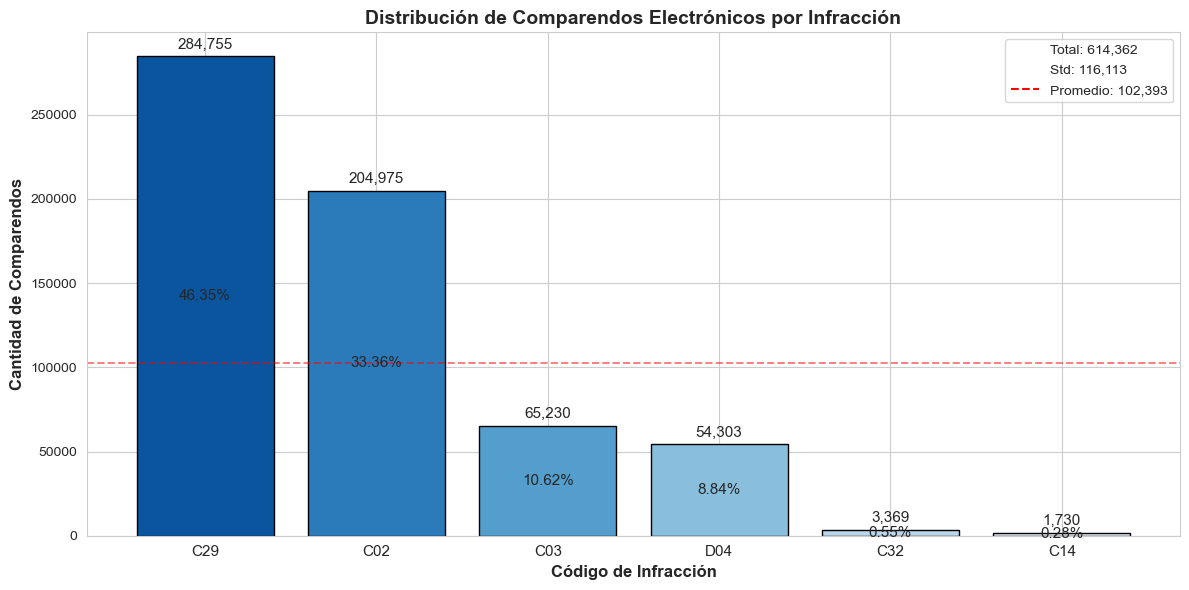

In [11]:
comparendos_por_infraccion = df_comparendos_electronicos.groupby('COD_INFRACCION')['CANTIDAD_INFRACCIONES'].sum().sort_values(ascending=False)
porcentajes = (comparendos_por_infraccion / total_infracciones * 100).round(2)

desviacion_estandar = comparendos_por_infraccion.std()

df_grafico = pd.DataFrame({
    'Código de Infracción': comparendos_por_infraccion.index,
    'Comparendos': comparendos_por_infraccion.values,
    'Porcentaje': porcentajes.values
})

print("Distribución de Comparendos Electrónicos por Código de Infracción")
display(df_grafico)

display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))

descripciones = df_comparendos_electronicos.groupby('COD_INFRACCION')['DESC_INFRACCION'].first().reset_index()
descripciones = descripciones.set_index('COD_INFRACCION').loc[df_grafico['Código de Infracción']].reset_index()
print("Descripción de los Códigos de Infracción")

pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_colwidth', None) 
display(descripciones)
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

colors = sns.color_palette("Blues", n_colors=len(df_grafico))
colors = colors[::-1]  

bars = plt.bar(range(len(df_grafico)), df_grafico['Comparendos'], color=colors, edgecolor='black', linewidth=1)

plt.title('Distribución de Comparendos Electrónicos por Infracción', fontsize=14, fontweight='bold')
plt.xlabel('Código de Infracción', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de Comparendos', fontsize=12, fontweight='bold')
plt.xticks(range(len(df_grafico)), df_grafico['Código de Infracción'], fontsize=11)

for i, (bar, conteo, porcentaje) in enumerate(zip(bars, df_grafico['Comparendos'], df_grafico['Porcentaje'])):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(df_grafico['Comparendos'])*0.01),
             f'{int(conteo):,}', ha='center', va='bottom', fontsize=11)
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
             f'{porcentaje}%', ha='center', va='center', fontsize=11)

plt.axhline(y=total_infracciones/len(df_grafico), linewidth=1.4, color='red', linestyle='--', alpha=0.5)

plt.legend(loc='upper right', handles=[
    plt.Line2D([0], [0], color='white', label=f'Total: {int(total_infracciones):,}'),
    plt.Line2D([0], [0], color='white', label=f'Std: {int(desviacion_estandar):,}'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'Promedio: {int(total_infracciones/len(df_grafico)):,}')
])

plt.tight_layout()
plt.show()

- **C29 - Exceso de velocidad (46.35%)**: Es la infracción más frecuente, concentrando casi la mitad del total de comparendos electrónicos (284,755 eventos). Este resultado evidencia que el exceso de velocidad es la principal causa de detección por parte de las cámaras de vigilancia.

- **C02 - Estacionar en sitios prohibidos (33.36%)**: Representa un tercio del total de infracciones (204,975 eventos), siendo la segunda causa más común. La alta incidencia de esta infracción sugiere una problemática significativa en cuanto al cumplimiento de las normas de estacionamiento.

- **C03 - Bloquear calzada o intersección (10.62%)**: Acumula el 10.62% de los comparendos (65,230 eventos), consolidándose como la tercera infracción más frecuente.

- **D04 - No detenerse ante un semáforo o una señal de «pare» (8.84%)**: Representa el 8.84% de los comparendos (54,303 eventos), evidenciando una problemática importante en el respeto de las señales de tránsito.

- **C32 - No respetar paso de peatones (0.55%)**: Con 3,369 eventos, su participación es baja en comparación con las infracciones anteriores.

- **C14 - Transitar por sitios restringidos o en horas prohibidad (0.28%)**: Es la infracción con menor participación (1,730 eventos), lo cual es coherente con su reciente implementación a través de las cámaras Carril Bus a partir del 17 de octubre de 2025.

---

**Comparación con el promedio:**

- **C29 (284,755)**: Supera ampliamente el promedio.
- **C02 (204,975)**: Duplica el promedio.
- **C03 (65,230)**: Se encuentra por debajo del promedio.
- **D04 (54,303)**: También por debajo del promedio.
- **C32 (3,369)**: Muy por debajo del promedio.
- **C14 (1,730)**: Extremadamente por debajo del promedio.


**Nota**: Las campañas de control y educación vial deberían enfocarse prioritariamente en el exceso de velocidad y el estacionamiento indebido.

## Análisis del Servicio del Vehículo Infractor

Se examina la distribución de los comparendos electrónicos según el servicio del vehículo infractor, utilizando la suma ponderada de `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones por cada categoría. Se calculan los porcentajes de participación y se presentan los resultados mediante una tabla de frecuencias, un gráfico de barras que muestra las cantidades absolutas con sus respectivos porcentajes, y un gráfico circular que ilustra la proporción relativa de cada categoría. Para mejorar la visualización, las categorías con menos de 1,000 infracciones se agrupan en una categoría "OTROS". Este análisis permite identificar qué tipo de servicio vehicular está más involucrado en las infracciones detectadas por el sistema de cámaras.

Distribución de Comparendos Electrónicos por Servicio del Vehículo


,Servicio del Vehículo,Comparendos,Porcentaje
0,PARTICULAR,525987,85.62
1,PUBLICO,87554,14.25
2,OFICIAL,819,0.13
3,DIPLOMATICO,2,0.00


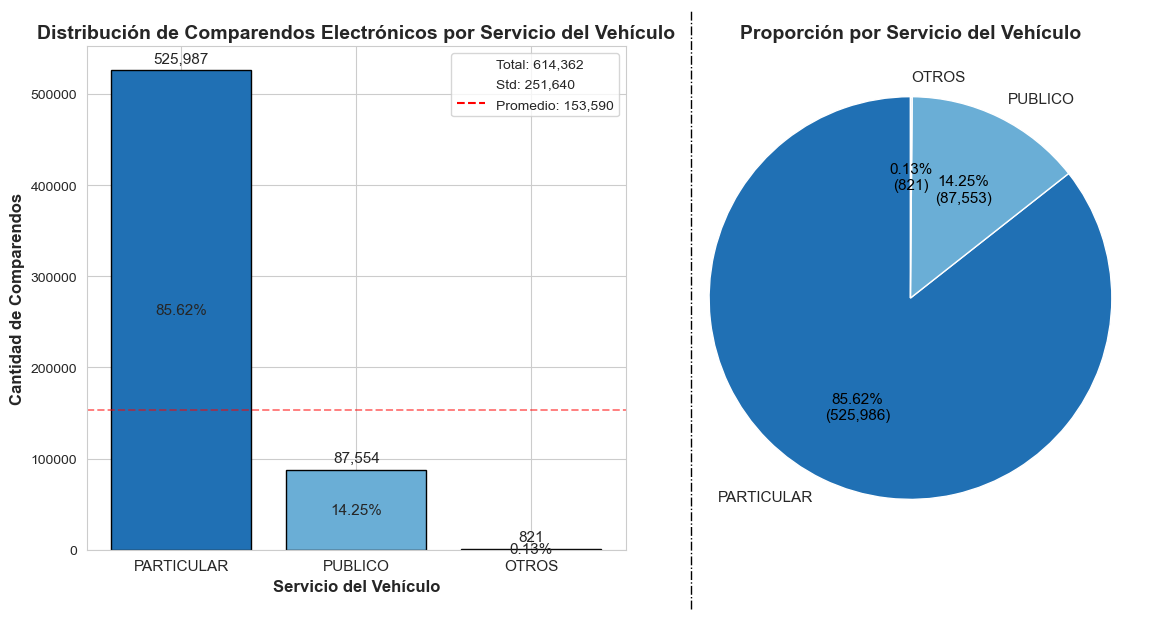

In [12]:
comparendos_por_servicio = df_comparendos_electronicos.groupby('SERVICIO_VEHICULO_INFRACTOR')['CANTIDAD_INFRACCIONES'].sum().sort_values(ascending=False)
porcentajes = (comparendos_por_servicio / total_infracciones * 100).round(2)

desviacion_estandar = comparendos_por_servicio.std()

df_original = pd.DataFrame({
    'Servicio del Vehículo': comparendos_por_servicio.index,
    'Comparendos': comparendos_por_servicio.values,
    'Porcentaje': porcentajes.values
})

print("Distribución de Comparendos Electrónicos por Servicio del Vehículo")
display(df_original)

display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))

servicios_otros = ['OFICIAL', 'DIPLOMATICO']

nuevas_categorias = [
    {'Servicio del Vehículo': 'PARTICULAR', 'Comparendos': df_original[df_original['Servicio del Vehículo'] == 'PARTICULAR']['Comparendos'].sum()},
    {'Servicio del Vehículo': 'PUBLICO', 'Comparendos': df_original[df_original['Servicio del Vehículo'] == 'PUBLICO']['Comparendos'].sum()},
    {'Servicio del Vehículo': 'OTROS', 'Comparendos': df_original[df_original['Servicio del Vehículo'].isin(servicios_otros)]['Comparendos'].sum()}
]

df_agrupado = pd.DataFrame(nuevas_categorias)
df_agrupado = df_agrupado.sort_values('Comparendos', ascending=False).reset_index(drop=True)
df_agrupado['Porcentaje'] = (df_agrupado['Comparendos'] / total_infracciones * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.set_style("whitegrid")

colors = sns.color_palette("Blues", n_colors=len(df_agrupado))
colors = colors[::-1]  

bars = axes[0].bar(range(len(df_agrupado)), df_agrupado['Comparendos'], color=colors, edgecolor='black', linewidth=1)
axes[0].set_title('Distribución de Comparendos Electrónicos por Servicio del Vehículo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Servicio del Vehículo', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad de Comparendos', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(len(df_agrupado)))
axes[0].set_xticklabels(df_agrupado['Servicio del Vehículo'], fontsize=11)

for i, (bar, conteo, porcentaje) in enumerate(zip(bars, df_agrupado['Comparendos'], df_agrupado['Porcentaje'])):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(df_agrupado['Comparendos'])*0.01),
                 f'{int(conteo):,}', ha='center', va='bottom', fontsize=11)
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
                 f'{porcentaje}%', ha='center', va='center', fontsize=11)

axes[0].axhline(y=total_infracciones/len(comparendos_por_servicio), linewidth=1.4, color='red', linestyle='--', alpha=0.5)

axes[0].legend(loc='upper right', handles=[
    plt.Line2D([0], [0], color='white', label=f'Total: {int(total_infracciones):,}'),
    plt.Line2D([0], [0], color='white', label=f'Std: {int(desviacion_estandar):,}'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'Promedio: {int(total_infracciones/len(comparendos_por_servicio)):,}')
])


fig.add_artist(plt.Line2D([0.58, 0.58], [0, 1], transform=fig.transFigure, color='black', linewidth=1, linestyle='dashdot', alpha=1))

wedges, texts, autotexts = axes[1].pie(df_agrupado['Comparendos'], 
                                        labels=df_agrupado['Servicio del Vehículo'],
                                        autopct=lambda pct: f'{pct:.2f}%\n({int(pct/100*total_infracciones):,})',
                                        startangle=90,
                                        colors=colors,
                                        textprops={'fontsize': 11})
for autotext in autotexts:
    autotext.set_color('black')

axes[1].set_title('Proporción por Servicio del Vehículo', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

- **Vehículos particulares (85.62%)**: Constituyen la categoría predominante, concentrando la mayoría del total de infracciones (525,987 eventos). Este resultado evidencia que los conductores de vehículos particulares son los principales infractores detectados por el sistema de cámaras.

- **Vehículos de servicio público (14.25%)**: Representan aproximadamente una séptima parte del total de infracciones (87,554 eventos). Aunque su participación es significativamente menor que la de los particulares, sigue siendo una proporción relevante que merece atención.

- **Otros (0.13%)**: Con solo 821 infracciones, su participación es marginal en el total de comparendos.

---

**Comparación con el promedio:**

- **Vehículos particulares (525,987)**: Superan ampliamente el promedio.
- **Vehículos de servicio público (87,554)**: Se encuentran por debajo del promedio.
- **Vehículos oficiales (819)**: Muy por debajo del promedio.
- **Vehículos diplomáticos (2)**: Extremadamente por debajo del promedio.

**Nota**: Las campañas de educación y control deberían estar dirigidas prioritariamente a conductores de vehículos particulares, dado que constituyen el grupo con mayor incidencia de infracciones. Además, aunque los vehículos de servicio público tienen menor participación, su impacto en la seguridad vial y la percepción ciudadana podría ameritar acciones específicas.


## Análisis de la Clase del Vehículo Infractor

Se examina la distribución de los comparendos electrónicos según la clase del vehículo infractor, utilizando la suma ponderada de `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones por cada categoría. Se calculan los porcentajes de participación y se presentan los resultados mediante una tabla de frecuencias. Posteriormente, se realiza una reclasificación de las categorías originales agrupando los vehículos pesados (camión, bus, microbús, buseta, volqueta, tractocamión) y otras clases minoritarias (motocarro, cuatrimoto, no reportado, sin clase) en dos nuevas categorías, con el fin de facilitar la visualización y el análisis comparativo entre los tipos de vehículo de mayor relevancia. El gráfico de barras resultante permite identificar qué tipos de vehículos están más involucrados en las infracciones detectadas por el sistema de cámaras.

Distribución de Comparendos Electrónicos por Clase del Vehículo


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
Clase del Vehículo,AUTOMOVIL,CAMIONETA,MOTOCICLETA,CAMPERO,CAMION,BUS,MICROBUS,BUSETA,VOLQUETA,TRACTOCAMION,MOTOCARRO,CUATRIMOTO,NO REPORTADO,SIN CLASE
Comparendos,321955,129827,102708,39955,9117,5585,2248,1501,706,579,168,7,5,1
Porcentaje,52.4,21.13,16.72,6.5,1.48,0.91,0.37,0.24,0.11,0.09,0.03,0.0,0.0,0.0


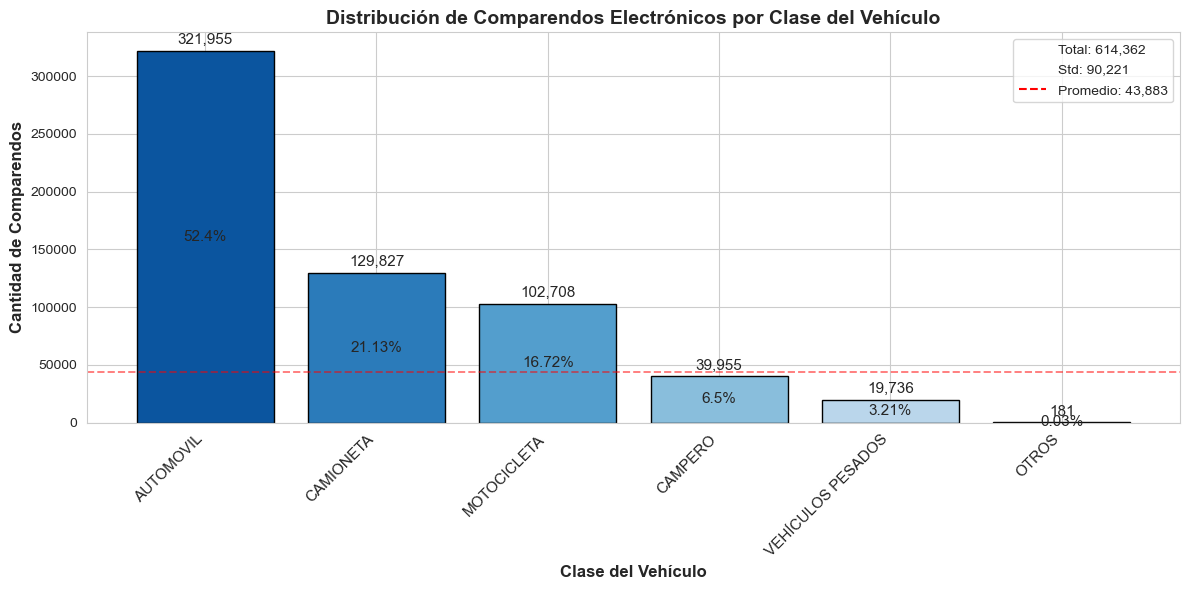

In [13]:
comparendos_por_clase = df_comparendos_electronicos.groupby('CLASE_VEHICULO_INFRACTOR')['CANTIDAD_INFRACCIONES'].sum().sort_values(ascending=False)
porcentajes = (comparendos_por_clase / total_infracciones * 100).round(2)

desviacion_estandar = comparendos_por_clase.std()

df_original = pd.DataFrame({
    'Clase del Vehículo': comparendos_por_clase.index,
    'Comparendos': comparendos_por_clase.values,
    'Porcentaje': porcentajes.values
})

print("Distribución de Comparendos Electrónicos por Clase del Vehículo")
display(df_original.T)

display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))

vehiculos_pesados = ['CAMION', 'BUS', 'MICROBUS', 'BUSETA', 'VOLQUETA', 'TRACTOCAMION']
otros = ['MOTOCARRO', 'CUATRIMOTO', 'NO REPORTADO', 'SIN CLASE']

nuevas_categorias = [
    {'Clase del Vehículo': 'AUTOMOVIL', 'Comparendos': df_original[df_original['Clase del Vehículo'] == 'AUTOMOVIL']['Comparendos'].sum()},
    {'Clase del Vehículo': 'CAMIONETA', 'Comparendos': df_original[df_original['Clase del Vehículo'] == 'CAMIONETA']['Comparendos'].sum()},
    {'Clase del Vehículo': 'MOTOCICLETA', 'Comparendos': df_original[df_original['Clase del Vehículo'] == 'MOTOCICLETA']['Comparendos'].sum()},
    {'Clase del Vehículo': 'CAMPERO', 'Comparendos': df_original[df_original['Clase del Vehículo'] == 'CAMPERO']['Comparendos'].sum()},
    {'Clase del Vehículo': 'VEHÍCULOS PESADOS', 'Comparendos': df_original[df_original['Clase del Vehículo'].isin(vehiculos_pesados)]['Comparendos'].sum()},
    {'Clase del Vehículo': 'OTROS', 'Comparendos': df_original[df_original['Clase del Vehículo'].isin(otros)]['Comparendos'].sum()}
]

df_agrupado = pd.DataFrame(nuevas_categorias)
df_agrupado = df_agrupado.sort_values('Comparendos', ascending=False).reset_index(drop=True)
df_agrupado['Porcentaje'] = (df_agrupado['Comparendos'] / total_infracciones * 100).round(2)

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

colors = sns.color_palette("Blues", n_colors=len(df_agrupado))
colors = colors[::-1]  

bars = plt.bar(range(len(df_agrupado)), df_agrupado['Comparendos'], color=colors, edgecolor='black', linewidth=1)

plt.title('Distribución de Comparendos Electrónicos por Clase del Vehículo', fontsize=14, fontweight='bold')
plt.xlabel('Clase del Vehículo', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de Comparendos', fontsize=12, fontweight='bold')
plt.xticks(range(len(df_agrupado)), df_agrupado['Clase del Vehículo'], fontsize=11, rotation=45, ha='right')

for i, (bar, conteo, porcentaje) in enumerate(zip(bars, df_agrupado['Comparendos'], df_agrupado['Porcentaje'])):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(df_agrupado['Comparendos'])*0.01),
             f'{int(conteo):,}', ha='center', va='bottom', fontsize=11)
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
             f'{porcentaje}%', ha='center', va='center', fontsize=11)

plt.axhline(y=total_infracciones/len(comparendos_por_clase), color='red', linewidth=1.4, linestyle='--', alpha=0.5)

plt.legend(loc='upper right', handles=[
    plt.Line2D([0], [0], color='white', label=f'Total: {int(total_infracciones):,}'),
    plt.Line2D([0], [0], color='white', label=f'Std: {int(desviacion_estandar):,}'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'Promedio: {int(total_infracciones/len(comparendos_por_clase)):,}')
])

plt.tight_layout()
plt.show()

- **Automóvil (52.40%)**: Es la clase de vehículo con mayor participación, concentrando la mayoría del total de infracciones (321,955 eventos).

- **Camioneta (21.13%)**: Constituye la segunda clase más infractora, con 129,827 infracciones, representando más de una quinta parte del total.

- **Motocicleta (16.72%)**: Ocupa el tercer lugar con 102,708 infracciones, equivalente a aproximadamente una sexta parte del total. A pesar de no ser la categoría predominante, su participación es significativa y merece atención por las implicaciones en seguridad vial.

- **Campero (6.50%)**: Con 39,955 infracciones, es la cuarta categoría en importancia, aunque con una participación mucho menor que las tres primeras.

---

**Concentración en tres clases principales:**

- **Automóvil**: 52.40%
- **Camioneta**: 21.13%
- **Motocicleta**: 16.72%
- **Total acumulado**: 90.25%

Este patrón refleja que los vehículos livianos de uso particular o particular-comercial son los principales protagonistas de las infracciones detectadas por el sistema de cámaras.

---

**Comparación con el promedio:**

- **Automóvil (321,955)**: Supera ampliamente el promedio.
- **Camioneta (129,827)**: Triplica el promedio.
- **Motocicleta (102,708)**: Más del doble del promedio.
- **Campero (39,955)**: Se aproxima al promedio.
- **Demás categorías**: Se encuentran por debajo del promedio, con participaciones decrecientes.

**Nota**: Las estrategias de prevención y control deben priorizar los vehículos livianos, especialmente automóviles y camionetas. Además, aunque las motocicletas tienen menor participación que automóviles y camionetas, su importancia en seguridad vial justifica acciones específicas.

## Análisis de las Cámaras

Se examina la distribución de los comparendos electrónicos según las cámaras presentes en el sistema, utilizando la suma ponderada de `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones por cada punto de control. Se presentan los resultados mediante una tabla de frecuencias que muestra todas las cámaras con sus respectivos conteos, porcentajes y fechas de primer y último registro, lo que permite evaluar la antigüedad y continuidad operativa de cada punto de control. Posteriormente, se destaca el top 5 de cámaras con mayor número de comparendos en un gráfico de barras. Adicionalmente, se realiza una agrupación temática que separa las cámaras dedicadas a la detección de "mal parqueo" de aquellas identificadas por su dirección, presentando un gráfico circular que compara la proporción de infracciones entre ambos grupos. Este análisis permite identificar los puntos críticos de detección de infracciones en la ciudad, evaluar el peso relativo de las cámaras especializadas en estacionamiento prohibido frente al resto del sistema de vigilancia, y conocer el período de operación de cada cámara para identificar posibles cambios en la nomenclatura o incorporaciones al sistema.

Distribución de Comparendos Electrónicos por Cámara


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55
Cámara y Dirección,Carro mal parqueo Sur,Carro mal parqueo Norte,VIA 11 CON CARRERA 8,Carro mal parqueo Sur - Norte,CARRERA 51B CON CALLE 79,CALLE 30 CON CARRERA 6B,CALLE 45 CON CARRERA 1,CALLE 30 CON CARRERA 8,CARRERA 53 CON CALLE 104,CALLE 82 CON CARRERA 51B,CARRERA 51B CON CALLE 103,Carro mal parqueo alto norte,CARRERA 6 CON CALLE 72,AVENIDA CIRCUNVALAR CON CARRERA 9G,VIA 40 CON CALLE 73,CALLE 45 CON CARRERA 20,CALLE 82 CON CARRERA 56,Carro mal parqueo alto sur,CALLE 45 CON CARRERA 21,CARRERA 15 CON CALLE 21,CALLE 45B CARRERA 14,CALLE 72 CON CARRERA 44,CALLE 84 CON CARRERA 59,CALLE 94 CON CARRERA 58,CARRERA 46 CON CALLE 100,CALLE 56 CON CARRERA 14,CALLE 19 CON CARRERA 4C,CALLE 87 CON CARRERA 21,CALLE 76 CON CARRERA 38C-100,CALLE 19 CON CARRERA 3D,CALLE 53 CON CARRERA 45,CARRERA 53 CON CALLE 86,CALLE 70 CON CARRERA 46,CALLE 34 CON CARRERA 45,CARRERA 53 ENTRE CALLE 104 Y 106,AVENIDA CIRCUNVALAR CON CARRERA 31,CALLE 98 CON CARRERA 56,CALLE 45 CON CARRERA 21 SENTIDO SUR-NORTE,CALLE 61 CON CARRERA 35,CALLE 45 CON CARRERA 21 SENTIDO NORTE-SUR,CALLE 45B CON CARRERA 14,CARRERA 45 CON CALLE 53,CARRERA 46 CON CALLE 34 SENTIDO SUR-NORTE,CALLE 70 CON CARRERA 46 SENTIDO SUR-NORTE,CALLE 84 ENTRE CARRERA 59 Y 59B,CARRERA 27 CON CALLE 82C,CALLE 70 CON CARRERA 46 SENTIDO NORTE-SUR,AVENIDA CIRCUNVALAR (CALLE 110) ENTRE CARRERA 9G Y 12 SENTIDO SUR A NORTE,CALLE 45 CON CARRERA 8 SENTIDO SUR-NORTE,AVENIDA CIRCUNVALAR (CALLE 110) ENTRE CARRERA 9G Y 12 SENTIDO NORTE A SUR,CALLE 45 CON CARRERA 33 SENTIDO NORTE-SUR,CALLE 45 CON CARRERA 43 SENTIDO SUR-NORTE,CALLE 45 CON CARRERA 43 SENTIDO NORTE-SUR,CALLE 45 CON CARRERA 1E SENTIDO SUR-NORTE,CARRERA 46 CON CALLE 34 SENTIDO NORTE-SUR,CALLE 45 CON CARRERA 1E SENTIDO NORTE-SUR
Comparendos,73544,65306,52029,37993,33293,24261,22800,21832,20593,19627,17116,17090,16292,16186,12983,12740,12032,11040,10036,9910,9520,8850,7958,7863,7705,7385,6980,6319,6236,6215,6030,4394,4241,3133,2386,2225,2128,1182,1176,1125,1048,751,725,562,521,390,300,102,69,66,32,18,9,8,4,3
Porcentaje,11.97,10.63,8.47,6.18,5.42,3.95,3.71,3.55,3.35,3.19,2.79,2.78,2.65,2.63,2.11,2.07,1.96,1.8,1.63,1.61,1.55,1.44,1.3,1.28,1.25,1.2,1.14,1.03,1.02,1.01,0.98,0.72,0.69,0.51,0.39,0.36,0.35,0.19,0.19,0.18,0.17,0.12,0.12,0.09,0.08,0.06,0.05,0.02,0.01,0.01,0.01,0.0,0.0,0.0,0.0,0.0
Primer Registro,2018-01-02,2018-01-02,2018-01-01,2018-09-29,2018-01-01,2018-01-01,2018-01-01,2018-01-01,2018-10-16,2018-01-10,2018-01-02,2023-06-28,2018-01-01,2018-01-01,2018-01-02,2018-01-01,2018-01-09,2023-08-15,2018-01-01,2018-01-01,2022-03-15,2018-01-10,2018-01-01,2018-01-01,2018-01-01,2018-01-01,2018-01-01,2018-01-01,2018-01-01,2018-01-01,2022-04-07,2018-01-01,2018-01-09,2018-01-03,2024-11-14,2018-01-01,2018-10-13,2024-11-24,2018-01-30,2024-11-22,2018-01-02,2018-01-04,2025-10-23,2025-10-21,2024-11-21,2018-01-02,2025-10-21,2024-11-29,2025-10-23,2024-12-06,2025-10-23,2025-10-25,2025-10-24,2025-10-21,2025-10-21,2025-10-21
Último Registro,2025-12-31,2025-12-31,2025-12-30,2025-12-30,2025-12-28,2025-12-30,2025-12-30,2025-12-31,2024-11-14,2025-12-30,2025-12-12,2025-12-31,2025-12-29,2024-11-28,2025-12-20,2024-11-19,2025-12-30,2025-12-31,2025-10-05,2025-12-19,2025-12-31,2025-11-07,2024-11-21,2025-08-31,2025-12-31,2021-05-03,2025-12-30,2021-05-24,2025-12-31,2025-12-28,2025-12-30,2022-07-19,2025-12-29,2025-12-31,2025-12-31,2019-07-23,2024-08-05,2025-12-28,2025-07-03,2025-12-31,2022-10-05,2021-01-14,2025-11-17,2025-12-31,2025-12-30,2020-03-02,2025-12-11,2025-10-08,2025-12-29,2025-12-29,2025-12-29,2025-11-05,2025-11-02,2025-10-24,2025-10-25,2025-10-23


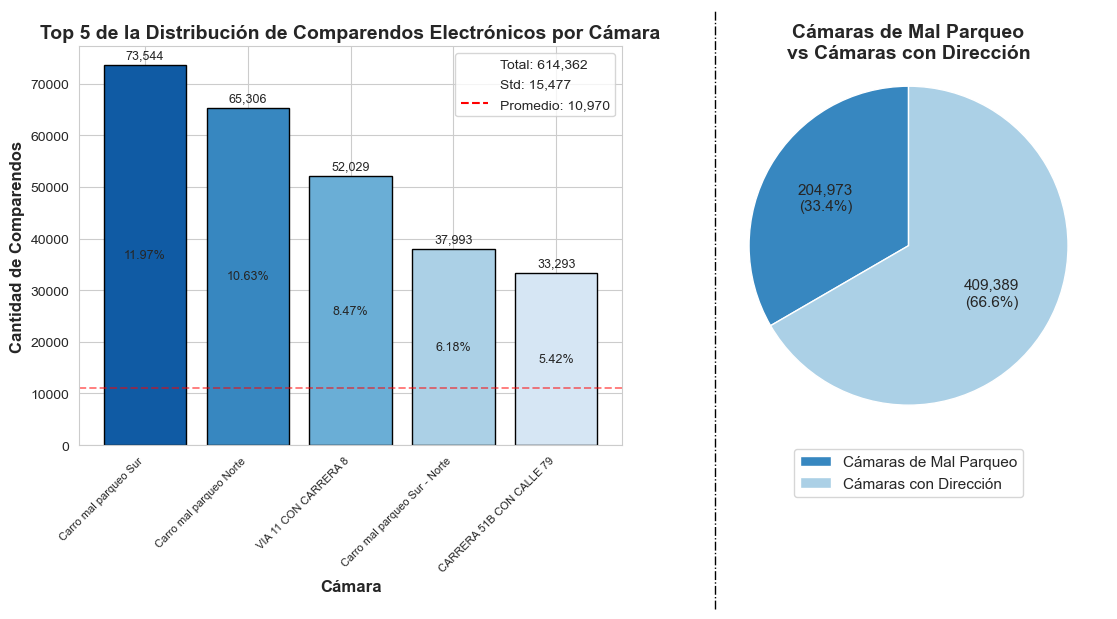

In [14]:
fechas_camaras = df_comparendos_electronicos.groupby('Camara_y_direccion')['fecha_comparendo'].agg(['min', 'max']).reset_index()
fechas_camaras.columns = ['Cámara y Dirección', 'Primer Registro', 'Último Registro']
fechas_camaras['Primer Registro'] = pd.to_datetime(fechas_camaras['Primer Registro']).dt.date
fechas_camaras['Último Registro'] = pd.to_datetime(fechas_camaras['Último Registro']).dt.date

comparendos_por_direccion = df_comparendos_electronicos.groupby('Camara_y_direccion')['CANTIDAD_INFRACCIONES'].sum().sort_values(ascending=False)
porcentajes = (comparendos_por_direccion / total_infracciones * 100).round(2)

desviacion_estandar = comparendos_por_direccion.std()

df_grafico = pd.DataFrame({
    'Cámara y Dirección': comparendos_por_direccion.index,
    'Comparendos': comparendos_por_direccion.values,
    'Porcentaje': porcentajes.values
})

df_grafico = df_grafico.merge(fechas_camaras, on='Cámara y Dirección')

print("Distribución de Comparendos Electrónicos por Cámara")
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_colwidth', None) 
display(df_grafico.T)
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))

top_5 = df_grafico.head(5)

categorias_mal_parqueo = df_grafico[df_grafico['Cámara y Dirección'].str.contains('mal', case=False, na=False)]
categorias_direccion = df_grafico[~df_grafico['Cámara y Dirección'].str.contains('mal', case=False, na=False)]

df_torta = pd.DataFrame({
    'Categoría': ['Cámaras de Mal Parqueo', 'Cámaras con Dirección'],
    'Comparendos': [categorias_mal_parqueo['Comparendos'].sum(), categorias_direccion['Comparendos'].sum()]
})
df_torta['Porcentaje'] = (df_torta['Comparendos'] / total_infracciones * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.set_style("whitegrid")

colors = sns.color_palette("Blues", n_colors=len(top_5))
colors = colors[::-1]

bars = axes[0].bar(range(len(top_5)), top_5['Comparendos'], color=colors, edgecolor='black', linewidth=1)
axes[0].set_title('Top 5 de la Distribución de Comparendos Electrónicos por Cámara', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cámara', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad de Comparendos', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(len(top_5)))
axes[0].set_xticklabels(top_5['Cámara y Dirección'], fontsize=8, rotation=45, ha='right')

for i, (bar, conteo, porcentaje) in enumerate(zip(bars, top_5['Comparendos'], top_5['Porcentaje'])):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(top_5['Comparendos'])*0.01),
                 f'{int(conteo):,}', ha='center', va='bottom', fontsize=9)
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
                 f'{porcentaje}%', ha='center', va='center', fontsize=9)

axes[0].axhline(y=total_infracciones/len(df_grafico), linewidth=1.4, color='red', linestyle='--', alpha=0.5)

axes[0].legend(loc='upper right', handles=[
    plt.Line2D([0], [0], color='white', label=f'Total: {int(total_infracciones):,}'),
    plt.Line2D([0], [0], color='white', label=f'Std: {int(desviacion_estandar):,}'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'Promedio: {int(total_infracciones/len(df_grafico)):,}')
])

colors_torta = sns.color_palette("Blues", n_colors=len(df_torta))
colors_torta = colors_torta[::-1]

fig.add_artist(plt.Line2D([0.6, 0.6], [0, 1], transform=fig.transFigure, color='black', linewidth=1, linestyle='dashdot', alpha=1))

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{val:,}\n({pct:.1f}%)'
    return my_autopct

wedges, texts, autotexts = axes[1].pie(df_torta['Comparendos'], 
                                        labels=None,
                                        autopct=make_autopct(df_torta['Comparendos']),
                                        startangle=90,
                                        colors=colors_torta,
                                        textprops={'fontsize': 11})

axes[1].legend(df_torta['Categoría'], loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=1, fontsize=11)

axes[1].set_title('Cámaras de Mal Parqueo\nvs Cámaras con Dirección', fontsize=14, fontweight='bold', loc='center', y=0.95)

plt.tight_layout()
plt.show()

- **Alta concentración en primeras ubicaciones**: Las primeras 5 cámaras concentran el **42.67%** del total de infracciones. Además, las primeras 10 cámaras representan aproximadamente el **60.42%** del total.

- **Dominancia de cámaras de mal parqueo**: Tres de las cinco primeras posiciones corresponden a cámaras de "mal parqueo" (posiciones 1, 2 y 4). Además, en el top 20 aparecen cinco cámaras de mal parqueo (posiciones 1, 2, 4, 12 y 18).

- **Cámara con dirección más activa**: "VIA 11 CON CARRERA 8" es la cámara con dirección que registra mayor volumen, ubicándose en la tercera posición con 52,029 infracciones (8.47%).

---

**Comparación con el promedio:**

- **Cámaras que superan el promedio**: 18 ubicaciones.
- **Cámaras por debajo del promedio**: 38 ubicaciones.

---

**Hallazgos:**

- **Dominancia de cámaras de mal parqueo**: Aunque representan solo 5 de las 56 ubicaciones, concentran el **33.36%** de todas las infracciones, lo que evidencia su alta efectividad en la detección de estacionamiento prohibido (infracción C02).

- **Puntos críticos claramente identificados**: Las cámaras "Carro mal parqueo Sur" y "Carro mal parqueo Norte" son, por sí solas, responsables del **22.60%** del total de comparendos, consolidándose como los puntos de control más estratégicos.

- **Alta variabilidad entre ubicaciones**: La desviación estándar (15,477) superior al promedio (10,970) confirma una distribución muy desigual, donde pocas cámaras concentran la mayor parte de las detecciones.

---

**Notas**:
- Las cámaras de mal parqueo deberían ser prioritarias en términos de mantenimiento y operación.
- Las ubicaciones con muy bajo rendimiento podrían evaluarse para determinar si su ubicación es estratégica o si requieren reubicación.
- La alta concentración sugiere que existen corredores viales y zonas específicas donde la infracción es recurrente, lo que podría orientar políticas de educación y control.

---

**Evolución en la nomenclatura de cámaras** 

En la base de datos se identificó que varias cámaras que inicialmente estaban registradas como un único punto de control sin especificación de sentido fueron posteriormente divididas en dos cámaras distintas según la dirección de circulación que vigilan (Norte-Sur y Sur-Norte). Un ejemplo claro de esto es la cámara ubicada en "CALLE 70 CON CARRERA 46", que originalmente aparecía con esa única notación y luego se incorporaron dos registros diferenciados: "CALLE 70 CON CARRERA 46 SENTIDO NORTE-SUR" y "CALLE 70 CON CARRERA 46 SENTIDO SUR-NORTE". En este caso, la cámara original "CALLE 70 CON CARRERA 46" siguió operando, pero hay casos en los que las cámaras originales dejaron de operar para dar paso a su división por sentido, como por ejemplo "AVENIDA CIRCUNVALAR CON CARRERA 9G", que luego evolucionó a "AVENIDA CIRCUNVALAR (CALLE 110) ENTRE CARRERA 9G Y 12 SENTIDO SUR A NORTE" y "AVENIDA CIRCUNVALAR (CALLE 110) ENTRE CARRERA 9G Y 12 SENTIDO NORTE A SUR". Aunque este cambio en la nomenclatura permite un mayor nivel de detalle en el análisis de infracciones al posibilitar identificar no solo el punto geográfico donde se cometió la infracción sino también el sentido de circulación del vehículo infractor, lo cual es relevante para entender patrones de movilidad y diseñar estrategias de control más precisas también dificulta los procesos de análisis, ya que fragmenta la información de un mismo punto de control en múltiples registros.

### Análisis Temporal de Cámaras Duplicadas

Se identificaron en la base de datos pares de nombres de cámaras que, a pesar de estar registrados con notaciones diferentes, representan el mismo punto físico de control. Para cada par, se grafica la evolución mensual de comparendos de ambas notaciones a lo largo del tiempo, con el objetivo de determinar si se trata efectivamente de la misma cámara (observando continuidad temporal entre ambas series) o si corresponden a puntos distintos. El análisis incluye un área sombreada que destaca el período crítico de la pandemia de COVID-19.

In [15]:
df_comparendos_electronicos_copy = df_comparendos_electronicos.copy()
df_comparendos_electronicos_copy['año_mes'] = df_comparendos_electronicos_copy['fecha_comparendo'].dt.to_period('M').astype(str)

pares_camaras = [
    (['CARRERA 53 CON CALLE 104', 'CARRERA 53 ENTRE CALLE 104 Y 106'], 'CON CALLE 104 / ENTRE CALLE 104 Y 106'),
    (['CALLE 84 CON CARRERA 59', 'CALLE 84 ENTRE CARRERA 59 Y 59B'], 'CON CARRERA 59 / ENTRE CARRERA 59 Y 59B'),
    (['CARRERA 45 CON CALLE 53', 'CALLE 53 CON CARRERA 45'], 'CARRERA 45 / CALLE 53'),
    (['CALLE 45B CARRERA 14', 'CALLE 45B CON CARRERA 14'], 'CARRERA 14 / CON CARRERA 14')
]

meses = sorted(df_comparendos_electronicos_copy['año_mes'].unique())

colores_par = ['cornflowerblue', 'mediumpurple']

for i, (camaras, titulo_par) in enumerate(pares_camaras):
    fig = go.Figure()
    
    for j, camara in enumerate(camaras):
        df_camara = df_comparendos_electronicos_copy[df_comparendos_electronicos_copy['Camara_y_direccion'] == camara]
        
        df_camara_mensual = df_camara.groupby('año_mes')['CANTIDAD_INFRACCIONES'].sum().reset_index()
        
        df_camara_mensual = df_camara_mensual.sort_values('año_mes')
        
        nombre_linea = camara
        fig.add_trace(go.Scatter(
            x=df_camara_mensual['año_mes'],
            y=df_camara_mensual['CANTIDAD_INFRACCIONES'],
            mode='lines+markers',
            name=nombre_linea,
            line=dict(color=colores_par[j], width=2),
            marker=dict(size=4),
            hovertemplate=f'{camara}<br>Mes: %{{x}}<br>Comparendos: %{{y:,.0f}}<extra></extra>'
        ))
    
    fig.add_vrect(
        x0="2020-03", x1="2020-12",
        fillcolor="red", opacity=0.1,
        line_width=0,
        annotation_text="COVID-19", 
        annotation_position="top left",
        annotation=dict(font_size=12, font_color="red")
    )
    
    fig.update_layout(
        title=dict(
            text=f'{titulo_par}',
            x=0.5,
            xanchor='center',
            font=dict(size=16, weight='bold')
        ),
        xaxis_title=dict(
            text='Año-Mes',
            font=dict(weight='bold')
        ),
        yaxis_title=dict(
            text='Cantidad de Comparendos',
            font=dict(weight='bold')
        ),
        template='plotly_white',
        hovermode='x unified',
        legend=dict(
            x=1, 
            y=1, 
            xanchor='center',
            yanchor='top',
            bgcolor='rgba(255,255,255,0.8)',
            font=dict(size=11),
            title='Cámara'
        ),
        width=1055, 
        height=500
    )

    tick_positions = meses[::6]
    fig.update_xaxes(
        tickangle=-45,
        tickvals=tick_positions,
        ticktext=tick_positions
    )
    
    fig.show()

#### Corrección de Cámaras Duplicadas

Se unifican los nombres de las cámaras que presentan dos notaciones diferentes para el mismo punto de control. Esta corrección permite evitar la duplicación de ubicaciones en los análisis y garantizar la consistencia de los datos.

In [16]:
df_comparendos_electronicos.loc[df_comparendos_electronicos['Camara_y_direccion'] == 'CARRERA 53 CON CALLE 104', 'Camara_y_direccion'] = 'CARRERA 53 ENTRE CALLE 104 Y 106'

df_comparendos_electronicos.loc[df_comparendos_electronicos['Camara_y_direccion'] == 'CALLE 84 CON CARRERA 59', 'Camara_y_direccion'] = 'CALLE 84 ENTRE CARRERA 59 Y 59B'

df_comparendos_electronicos.loc[df_comparendos_electronicos['Camara_y_direccion'] == 'CARRERA 45 CON CALLE 53', 'Camara_y_direccion'] = 'CALLE 53 CON CARRERA 45'

df_comparendos_electronicos.loc[df_comparendos_electronicos['Camara_y_direccion'] == 'CALLE 45B CARRERA 14', 'Camara_y_direccion'] = 'CALLE 45B CON CARRERA 14'

### Análisis de las Cámaras de "Mal Parqueo"

Se examina de manera específica la distribución de los comparendos electrónicos generados exclusivamente por las cinco cámaras dedicadas a la detección de estacionamiento prohibido (infracción C02). Para ello, se filtran las ubicaciones que contienen la denominación "mal parqueo", se suman sus respectivos volúmenes de infracciones y se calculan estadísticos descriptivos como el total del grupo, el promedio y la desviación estándar. Los porcentajes presentados corresponden a la participación de cada cámara dentro del subgrupo de mal parqueo, permitiendo comparar el peso relativo de cada una. Los resultados se presentan mediante una tabla de frecuencias y un gráfico de barras que facilita la comparación visual del desempeño individual de cada cámara especializada.

Distribución de Comparendos Electrónicos por Cámara de Mal Parqueo


,0,1,3,11,17
Cámara y Dirección,Carro mal parqueo Sur,Carro mal parqueo Norte,Carro mal parqueo Sur - Norte,Carro mal parqueo alto norte,Carro mal parqueo alto sur
Comparendos,73544,65306,37993,17090,11040
Porcentaje,35.88,31.86,18.54,8.34,5.39
Primer Registro,2018-01-02,2018-01-02,2018-09-29,2023-06-28,2023-08-15
Último Registro,2025-12-31,2025-12-31,2025-12-30,2025-12-31,2025-12-31


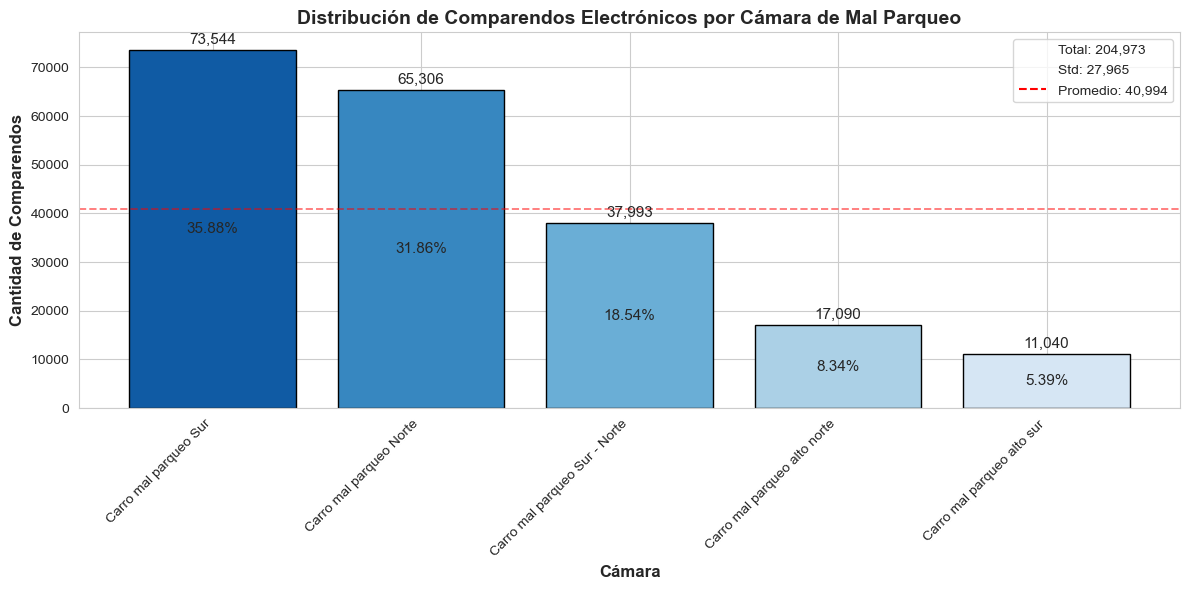

In [17]:
fechas_camaras = df_comparendos_electronicos.groupby('Camara_y_direccion')['fecha_comparendo'].agg(['min', 'max']).reset_index()
fechas_camaras.columns = ['Cámara y Dirección', 'Primer Registro', 'Último Registro']
fechas_camaras['Primer Registro'] = pd.to_datetime(fechas_camaras['Primer Registro']).dt.date
fechas_camaras['Último Registro'] = pd.to_datetime(fechas_camaras['Último Registro']).dt.date

comparendos_por_direccion = df_comparendos_electronicos.groupby('Camara_y_direccion')['CANTIDAD_INFRACCIONES'].sum().sort_values(ascending=False)
total_infracciones = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].sum()
porcentajes = (comparendos_por_direccion / total_infracciones * 100).round(2)

desviacion_estandar = comparendos_por_direccion.std()

df_grafico = pd.DataFrame({
    'Cámara y Dirección': comparendos_por_direccion.index,
    'Comparendos': comparendos_por_direccion.values,
    'Porcentaje': porcentajes.values
})

df_grafico = df_grafico.merge(fechas_camaras, on='Cámara y Dirección')

categorias_mal_parqueo = df_grafico[df_grafico['Cámara y Dirección'].str.contains('mal', case=False, na=False)].copy()
categorias_direccion = df_grafico[~df_grafico['Cámara y Dirección'].str.contains('mal', case=False, na=False)].copy()

subtotal_mal_parqueo = categorias_mal_parqueo['Comparendos'].sum()

categorias_mal_parqueo['Porcentaje'] = (categorias_mal_parqueo['Comparendos'] / subtotal_mal_parqueo * 100).round(2)

total_mal_parqueo = categorias_mal_parqueo['Comparendos'].sum()
desviacion_mal_parqueo = categorias_mal_parqueo['Comparendos'].std()
promedio_mal_parqueo = categorias_mal_parqueo['Comparendos'].mean()

print("Distribución de Comparendos Electrónicos por Cámara de Mal Parqueo")
display(categorias_mal_parqueo.T)

display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

colors = sns.color_palette("Blues", n_colors=len(categorias_mal_parqueo))
colors = colors[::-1]

bars = plt.bar(range(len(categorias_mal_parqueo)), categorias_mal_parqueo['Comparendos'], color=colors, edgecolor='black', linewidth=1)

plt.title('Distribución de Comparendos Electrónicos por Cámara de Mal Parqueo', fontsize=14, fontweight='bold')
plt.xlabel('Cámara', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de Comparendos', fontsize=12, fontweight='bold')
plt.xticks(range(len(categorias_mal_parqueo)), categorias_mal_parqueo['Cámara y Dirección'], fontsize=10, rotation=45, ha='right')

for i, (bar, conteo, porcentaje) in enumerate(zip(bars, categorias_mal_parqueo['Comparendos'], categorias_mal_parqueo['Porcentaje'])):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(categorias_mal_parqueo['Comparendos'])*0.01),
             f'{int(conteo):,}', ha='center', va='bottom', fontsize=11)
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
             f'{porcentaje}%', ha='center', va='center', fontsize=11)

plt.axhline(y=promedio_mal_parqueo, color='red', linewidth=1.4, linestyle='--', alpha=0.5)

plt.legend(loc='upper right', handles=[
    plt.Line2D([0], [0], color='white', label=f'Total: {int(total_mal_parqueo):,}'),
    plt.Line2D([0], [0], color='white', label=f'Std: {int(desviacion_mal_parqueo):,}'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'Promedio: {int(promedio_mal_parqueo):,}')
])

plt.tight_layout()
plt.show()

Las cámaras "Carro mal parqueo Sur" y "Carro mal parqueo Norte" concentran en conjunto el **67.74%** de las infracciones de este grupo (138,850 de 204,973).

**Jerarquía clara**:
- La cámara "Sur" es la más activa, con 73,544 infracciones (35.88% del grupo), superando a la segunda ("Norte") en 8,238 infracciones.
- La cámara "Sur - Norte" ocupa un lugar intermedio, con 37,993 infracciones (18.54% del grupo).
- Las cámaras "alto norte" y "alto sur" tienen un rendimiento considerablemente menor, sumando en conjunto 28,130 infracciones, que representan solo el **13.73%** del grupo.

---

**Comparación con el promedio:**

- **Carro mal parqueo Sur (73,544)**: Supera el promedio en 32,550 infracciones.
- **Carro mal parqueo Norte (65,306)**: Supera el promedio en 24,310 infracciones.
- **Carro mal parqueo Sur - Norte (37,993)**: Se encuentra ligeramente por debajo del promedio.
- **Carro mal parqueo alto norte (17,090)**: Se encuentra muy por debajo del promedio.
- **Carro mal parqueo alto sur (11,040)**: Se encuentra extremadamente por debajo del promedio.

---

**Análisis de dispersión**: La desviación estándar de **27,965** es considerablemente alta en relación con el promedio (40,995), lo que indica una **gran variabilidad** entre las cinco cámaras. Lo cual confirma que no todas las cámaras de mal parqueo tienen el mismo nivel de actividad, existiendo una marcada diferencia entre las dos principales y las tres restantes.

---

**Notas:**

- Estas cámaras "Carro mal parqueo Sur" y "Carro mal parqueo Norte" podrían estar ubicadas en puntos estratégicos de mayor flujo vehicular o zonas comerciales.
- Las cámaras "alto norte" y "alto sur" podrían estar en áreas con menor densidad de tráfico o mejor cumplimiento de las normas.
- Las cámaras "Sur" y "Norte" deben ser prioritarias en términos de operación y mantenimiento.

### Análisis de las Cámaras "Con Dirección"

Se examina la distribución de los comparendos electrónicos generados por las 51 cámaras identificadas por su ubicación y dirección específica, excluyendo las cinco cámaras dedicadas a la detección de "mal parqueo". Se calculan estadísticos descriptivos del grupo, incluyendo el total de infracciones, el promedio y la desviación estándar, y los porcentajes presentados corresponden a la participación de cada cámara dentro de este subgrupo. Los resultados se presentan mediante una tabla de frecuencias que muestra todas las ubicaciones con sus respectivos conteos y porcentajes internos, y un gráfico de barras que destaca las 5 cámaras con mayor número de comparendos dentro de esta categoría. Este análisis permite identificar los puntos críticos de detección de infracciones entre las cámaras que no están especializadas en estacionamiento prohibido, así como evaluar la variabilidad y concentración dentro de este grupo.

Distribución de Comparendos Electrónicos por Cámara Con Dirección


,2,4,5,6,7,8,9,10,12,13,14,15,16,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51
Cámara y Dirección,VIA 11 CON CARRERA 8,CARRERA 51B CON CALLE 79,CALLE 30 CON CARRERA 6B,CARRERA 53 ENTRE CALLE 104 Y 106,CALLE 45 CON CARRERA 1,CALLE 30 CON CARRERA 8,CALLE 82 CON CARRERA 51B,CARRERA 51B CON CALLE 103,CARRERA 6 CON CALLE 72,AVENIDA CIRCUNVALAR CON CARRERA 9G,VIA 40 CON CALLE 73,CALLE 45 CON CARRERA 20,CALLE 82 CON CARRERA 56,CALLE 45B CON CARRERA 14,CALLE 45 CON CARRERA 21,CARRERA 15 CON CALLE 21,CALLE 72 CON CARRERA 44,CALLE 84 ENTRE CARRERA 59 Y 59B,CALLE 94 CON CARRERA 58,CARRERA 46 CON CALLE 100,CALLE 56 CON CARRERA 14,CALLE 19 CON CARRERA 4C,CALLE 53 CON CARRERA 45,CALLE 87 CON CARRERA 21,CALLE 76 CON CARRERA 38C-100,CALLE 19 CON CARRERA 3D,CARRERA 53 CON CALLE 86,CALLE 70 CON CARRERA 46,CALLE 34 CON CARRERA 45,AVENIDA CIRCUNVALAR CON CARRERA 31,CALLE 98 CON CARRERA 56,CALLE 45 CON CARRERA 21 SENTIDO SUR-NORTE,CALLE 61 CON CARRERA 35,CALLE 45 CON CARRERA 21 SENTIDO NORTE-SUR,CARRERA 46 CON CALLE 34 SENTIDO SUR-NORTE,CALLE 70 CON CARRERA 46 SENTIDO SUR-NORTE,CARRERA 27 CON CALLE 82C,CALLE 70 CON CARRERA 46 SENTIDO NORTE-SUR,AVENIDA CIRCUNVALAR (CALLE 110) ENTRE CARRERA 9G Y 12 SENTIDO SUR A NORTE,CALLE 45 CON CARRERA 8 SENTIDO SUR-NORTE,AVENIDA CIRCUNVALAR (CALLE 110) ENTRE CARRERA 9G Y 12 SENTIDO NORTE A SUR,CALLE 45 CON CARRERA 33 SENTIDO NORTE-SUR,CALLE 45 CON CARRERA 43 SENTIDO SUR-NORTE,CALLE 45 CON CARRERA 43 SENTIDO NORTE-SUR,CALLE 45 CON CARRERA 1E SENTIDO SUR-NORTE,CARRERA 46 CON CALLE 34 SENTIDO NORTE-SUR,CALLE 45 CON CARRERA 1E SENTIDO NORTE-SUR
Comparendos,52029,33293,24261,22979,22800,21832,19627,17116,16292,16186,12983,12740,12032,10568,10036,9910,8850,8479,7863,7705,7385,6980,6781,6319,6236,6215,4394,4241,3133,2225,2128,1182,1176,1125,725,562,390,300,102,69,66,32,18,9,8,4,3
Porcentaje,12.71,8.13,5.93,5.61,5.57,5.33,4.79,4.18,3.98,3.95,3.17,3.11,2.94,2.58,2.45,2.42,2.16,2.07,1.92,1.88,1.8,1.7,1.66,1.54,1.52,1.52,1.07,1.04,0.77,0.54,0.52,0.29,0.29,0.27,0.18,0.14,0.1,0.07,0.02,0.02,0.02,0.01,0.0,0.0,0.0,0.0,0.0
Primer Registro,2018-01-01,2018-01-01,2018-01-01,2018-10-16,2018-01-01,2018-01-01,2018-01-10,2018-01-02,2018-01-01,2018-01-01,2018-01-02,2018-01-01,2018-01-09,2018-01-02,2018-01-01,2018-01-01,2018-01-10,2018-01-01,2018-01-01,2018-01-01,2018-01-01,2018-01-01,2018-01-04,2018-01-01,2018-01-01,2018-01-01,2018-01-01,2018-01-09,2018-01-03,2018-01-01,2018-10-13,2024-11-24,2018-01-30,2024-11-22,2025-10-23,2025-10-21,2018-01-02,2025-10-21,2024-11-29,2025-10-23,2024-12-06,2025-10-23,2025-10-25,2025-10-24,2025-10-21,2025-10-21,2025-10-21
Último Registro,2025-12-30,2025-12-28,2025-12-30,2025-12-31,2025-12-30,2025-12-31,2025-12-30,2025-12-12,2025-12-29,2024-11-28,2025-12-20,2024-11-19,2025-12-30,2025-12-31,2025-10-05,2025-12-19,2025-11-07,2025-12-30,2025-08-31,2025-12-31,2021-05-03,2025-12-30,2025-12-30,2021-05-24,2025-12-31,2025-12-28,2022-07-19,2025-12-29,2025-12-31,2019-07-23,2024-08-05,2025-12-28,2025-07-03,2025-12-31,2025-11-17,2025-12-31,2020-03-02,2025-12-11,2025-10-08,2025-12-29,2025-12-29,2025-12-29,2025-11-05,2025-11-02,2025-10-24,2025-10-25,2025-10-23


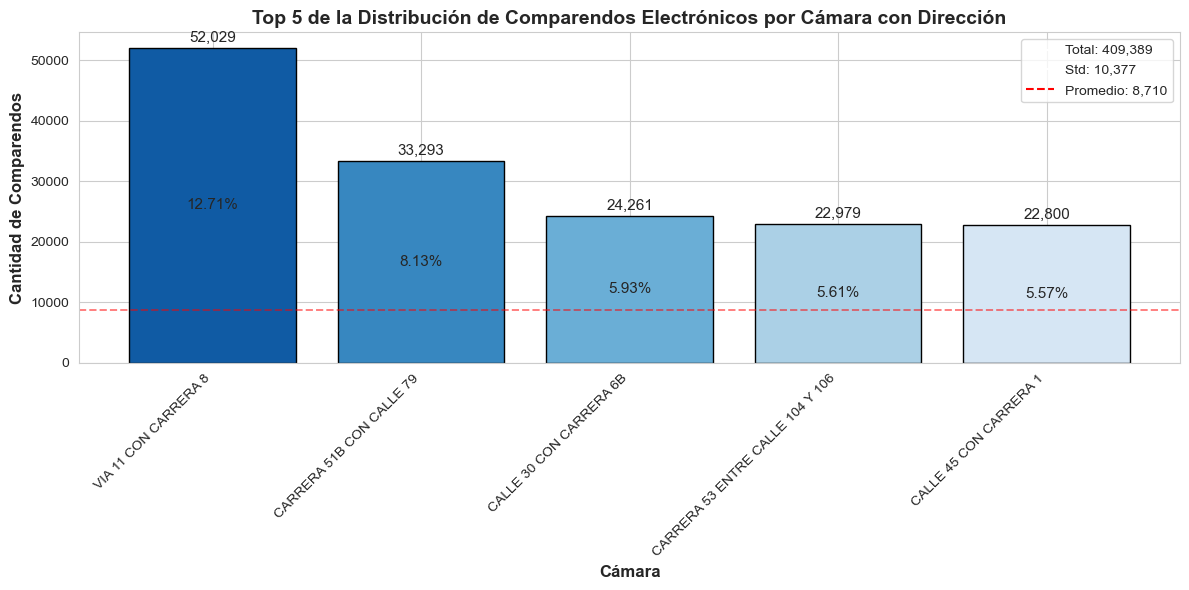

In [18]:
subtotal_direccion = categorias_direccion['Comparendos'].sum()

categorias_direccion['Porcentaje'] = (categorias_direccion['Comparendos'] / subtotal_direccion * 100).round(2)

total_direccion = categorias_direccion['Comparendos'].sum()
desviacion_direccion = categorias_direccion['Comparendos'].std()
promedio_direccion = categorias_direccion['Comparendos'].mean()

top_5_direccion = categorias_direccion.head(5)

print("Distribución de Comparendos Electrónicos por Cámara Con Dirección")
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_colwidth', None) 
display(categorias_direccion.T)
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

colors = sns.color_palette("Blues", n_colors=len(top_5_direccion))
colors = colors[::-1]

bars = plt.bar(range(len(top_5_direccion)), top_5_direccion['Comparendos'], color=colors, edgecolor='black', linewidth=1)

plt.title('Top 5 de la Distribución de Comparendos Electrónicos por Cámara con Dirección', fontsize=14, fontweight='bold')
plt.xlabel('Cámara', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de Comparendos', fontsize=12, fontweight='bold')
plt.xticks(range(len(top_5_direccion)), top_5_direccion['Cámara y Dirección'], fontsize=10, rotation=45, ha='right')

for i, (bar, conteo, porcentaje) in enumerate(zip(bars, top_5_direccion['Comparendos'], top_5_direccion['Porcentaje'])):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(top_5_direccion['Comparendos'])*0.01),
             f'{int(conteo):,}', ha='center', va='bottom', fontsize=11)
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
             f'{porcentaje}%', ha='center', va='center', fontsize=11)

plt.axhline(y=promedio_direccion, color='red', linewidth=1.4, linestyle='--', alpha=0.5)

plt.legend(loc='upper right', handles=[
    plt.Line2D([0], [0], color='white', label=f'Total: {int(total_direccion):,}'),
    plt.Line2D([0], [0], color='white', label=f'Std: {int(desviacion_direccion):,}'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'Promedio: {int(promedio_direccion):,}')
])

plt.tight_layout()
plt.show()

**Alta concentración en las primeras cámaras**:
- La cámara "VIA 11 CON CARRERA 8" concentra el **12.71%** del total de infracciones del grupo, siendo la más activa entre las cámaras con dirección.
- Las primeras 5 cámaras concentran el **37.95%** del grupo.
- Las primeras 10 cámaras concentran el **60.18%** del grupo.

**Distribución geográfica destacada**:
- **Corredor de la CALLE 30**: Aparecen dos cámaras en esta vía (con CARRERA 6B y CARRERA 8), sumando 46,093 infracciones (11.26% del grupo).
- **Corredor de la CARRERA 51B**: Aparecen dos cámaras (con CALLE 79 y CALLE 103), sumando 50,409 infracciones (12.31% del grupo).
- **Avenida Circunvalar**: Presente con dos cámaras (CARRERA 9G y CARRERA 31), sumando 18,411 infracciones (4.49% del grupo).


---

**Comparación con el promedio:**

- **Cámaras que superan el promedio**: 17 ubicaciones.
- **Cámaras por debajo del promedio**: 34 ubicaciones.

---

**Análisis de dispersión:** La desviación estándar de **10,377** es superior al promedio (8,710), lo que indica una **alta variabilidad** entre las cámaras de este grupo. Confirmando que existe una marcada diferencia entre las cámaras más activas y las menos activas, aunque esta dispersión es menor que la observada en el grupo de mal parqueo.

---

**Hallazgos:**

- **Cámara más activa del sistema**: "VIA 11 CON CARRERA 8" es la cámara con dirección que más infracciones detecta (52,029), representando el 12.71% del grupo y el 8.47% del total general.

- **Corredores viales críticos**: Los corredores de la CARRERA 51B y la CALLE 30 concentran una alta proporción de infracciones, lo que sugiere que estas vías requieren especial atención en términos de control y educación vial.

- **Alta heterogeneidad dentro del grupo**: Aunque todas las cámaras comparten la función de detectar infracciones en ubicaciones específicas, existe una marcada diferencia en su rendimiento.

-  **Importancia de los sentidos de circulación**: En algunas ubicaciones, la dirección de circulación influye significativamente en el volumen de infracciones (por ejemplo, CALLE 70 CON CARRERA 46 tiene casi el doble de infracciones en sentido SUR-NORTE que en NORTE-SUR).

---

**Notas:**

   - Las cámaras con mayor actividad deben ser prioritarias en mantenimiento y operación.
   - Las cámaras con muy bajo rendimiento podrían evaluarse para determinar si su ubicación es estratégica o si requieren reubicación.
   - Los corredores viales con alta concentración de infracciones podrían beneficiarse de campañas educativas específicas.

## Evolución Anual de Comparendos Electrónicos

Se examina la evolución anual de los comparendos electrónicos, agrupando los registros por año de la fecha del comparendo y sumando la columna `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones por cada período. Se presentan los resultados mediante una tabla de frecuencias que muestra la cantidad y el porcentaje de infracciones por año, junto con estadísticos descriptivos como el promedio anual, la desviación estándar, y los años con valores máximo y mínimo. Complementariamente, se genera un gráfico de líneas interactivo que ilustra la tendencia temporal, destacando el promedio general, los puntos extremos y el período crítico de la pandemia de COVID-19 mediante un área sombreada. Este análisis permite identificar patrones de crecimiento o disminución en la detección de infracciones a lo largo del tiempo, evaluar la variabilidad entre años, y contextualizar el impacto de eventos externos como las restricciones de movilidad en el comportamiento de los comparendos electrónicos.

In [19]:
infracciones_por_año = df_comparendos_electronicos.groupby(df_comparendos_electronicos['fecha_comparendo'].dt.year)['CANTIDAD_INFRACCIONES'].sum().sort_index()

total_infracciones = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].sum()
desviacion_estandar = infracciones_por_año.std()
promedio_anual = infracciones_por_año.mean()
max_anual = infracciones_por_año.max()
max_año = infracciones_por_año.idxmax()
min_anual = infracciones_por_año.min()
min_año = infracciones_por_año.idxmin()

df_anual = pd.DataFrame({
    'Año': infracciones_por_año.index,
    'Comparendos': infracciones_por_año.values,
    'Porcentaje': (infracciones_por_año.values / total_infracciones * 100).round(2)
}).sort_values('Comparendos', ascending=False).reset_index(drop=True)

print("Distribución de Comparendos Electrónicos por Año") 
display(df_anual.T)

display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=infracciones_por_año.index,
    y=infracciones_por_año.values,
    mode='lines+markers',
    name='Infracciones anuales',
    line=dict(color="cornflowerblue", width=2),
    marker=dict(size=8, color='cornflowerblue'),
    hovertemplate='Año: %{x}<br>Comparendos: %{y:,.0f}<extra></extra>',
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='none',
    name=f'Total: {int(total_infracciones):,}',
    showlegend=True
))

fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='none',
    name=f'Std: {int(desviacion_estandar):,}',
    showlegend=True
))

x_min = infracciones_por_año.index.min()
x_max = infracciones_por_año.index.max()
fig.add_trace(go.Scatter(
    x=[x_min, x_max],
    y=[promedio_anual, promedio_anual],
    mode='lines',
    name=f'Promedio: {int(promedio_anual):,}',
    line=dict(color='red', width=1.5, dash='dot'),
    showlegend=True,
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[max_año],
    y=[max_anual],
    mode='markers',
    name=f'Máximo: {max_año} ({int(max_anual):,})',
    marker=dict(size=10, color='red', symbol='circle'),
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[min_año],
    y=[min_anual],
    mode='markers',
    name=f'Mínimo: {min_año} ({int(min_anual):,})',
    marker=dict(size=10, color='green', symbol='circle'),
    hoverinfo='none'
))

fig.add_vrect(
    x0="2020", x1="2021",
    fillcolor="red", opacity=0.1,
    line_width=0,
    annotation_text="COVID-19", 
    annotation_position="top left",
    annotation=dict(font_size=12, font_color="red")
)

fig.update_layout(
    title=dict(
        text='Evolución Anual de Comparendos Electrónicos',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title=dict(
        text='Año',
        font=dict(weight='bold')
    ),
    yaxis_title=dict(
        text='Cantidad de Comparendos',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    hovermode='x unified',
    legend=dict(
        x=1, 
        y=1, 
        xanchor='center',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.5)',
        font=dict(size=12)
    ),
    width=1055, 
    height=500
)

fig.update_xaxes(tickmode='linear', tick0=2018, dtick=1)

fig.show()

Distribución de Comparendos Electrónicos por Año


,0,1,2,3,4,5,6,7
Año,2019.00,2023.00,2024.00,2018.00,2022.00,2020.00,2025.00,2021.00
Comparendos,98171.00,88402.00,87994.00,83741.00,80415.00,59526.00,59198.00,56915.00
Porcentaje,15.98,14.39,14.32,13.63,13.09,9.69,9.64,9.26


**Año de mayor detección (2019)**:
 - **2019** registra el mayor volumen con 98,171 infracciones (15.98% del total), posicionándose como el año con mayor actividad de detección del período analizado.

**Años de recuperación post-pandemia (2022-2024)**:
- **2023** y **2024** presentan volúmenes muy similares (88,402 y 87,994 respectivamente), ubicándose en segundo y tercer lugar.
- **2022** registra 80,415 infracciones (13.09%), ocupando el quinto lugar.
- Estos tres años(2022-2024) concentran el **41.80%** del total de infracciones.

**Años de menor detección (2020, 2021 y 2025)**:
   - **2021** presenta el valor más bajo del período con 56,915 infracciones (9.26%).
   - **2020** registra 59,526 infracciones (9.69%), ubicándose como el segundo año con menor volumen.
   - **2025** presenta 59,198 infracciones (9.64%), con un volumen similar al de 2020. Las posibles causas de este descenso serán analizadas en análisis posteriores.

---

**Impacto de la pandemia (2020-2021)**:
- En Colombia, las restricciones de movilidad más estrictas por la pandemia de COVID-19 se implementaron principalmente durante **2020**, con confinamientos obligatorios y medidas de distanciamiento social.
- A pesar de ello, **2021 presenta el volumen más bajo de infracciones**, incluso inferior a 2020. Este comportamiento podría explicarse por:
   - Cambios en los patrones de movilidad post-pandemia.
   - Posible ajustes en el funcionamiento del sistema de cámaras durante ese período.
   - situaciones externas que hayan influenciado en la movilidad en zonas con camáras de fotodetección.

**Recuperación progresiva (2022-2024)**:
- A partir de 2022, los volúmenes se recuperan y se estabilizan en niveles superiores a 80,000 infracciones anuales.
- El incremento de 2021 a 2022 es del **41.28%**, reflejando la reactivación total de la movilidad.

**Comportamiento de 2025**:
- El año 2025 presenta 59,198 infracciones, un volumen inferior al de 2023 y 2024, y similar al de 2020.
- Dado que el año se encuentra completo en la base de datos, este descenso no se debe a datos parciales. Las posibles causas serán exploradas en análisis posteriores.


## Evolución Mensual de Comparendos Electrónicos

Se examina la evolución mensual de los comparendos electrónicos a lo largo del período comprendido entre 2018 y 2025, agregando los registros por año-mes y sumando la columna `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones por cada período mensual. Se presentan los resultados mediante una tabla de frecuencias que muestra la cantidad y el porcentaje de infracciones por cada mes, y un gráfico de líneas interactivo que ilustra la tendencia temporal con marcadores destacados para los valores máximo y mínimo. Este análisis permite identificar patrones estacionales, detectar cambios significativos en la detección de infracciones a nivel mensual y evaluar el impacto de eventos específicos en la movilidad y el comportamiento de los conductores.

In [20]:
infracciones_por_mes = df_comparendos_electronicos_copy.groupby('año_mes')['CANTIDAD_INFRACCIONES'].sum().sort_index()

desviacion_estandar = infracciones_por_mes.std()
promedio_mensual = infracciones_por_mes.mean()
max_mensual = infracciones_por_mes.max()
max_mes = infracciones_por_mes.idxmax()
min_mensual = infracciones_por_mes.min()
min_mes = infracciones_por_mes.idxmin()

df_mensual = pd.DataFrame({
    'Año-Mes': infracciones_por_mes.index,
    'Comparendos': infracciones_por_mes.values,
    'Porcentaje': (infracciones_por_mes.values / total_infracciones * 100).round(2)
}).sort_values('Comparendos', ascending=False).reset_index(drop=True)

print("Distribución de Comparendos Electrónicos por Mes")
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_colwidth', None) 
display(df_mensual.T)
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=infracciones_por_mes.index,
    y=infracciones_por_mes.values,
    mode='lines+markers',
    line=dict(color='cornflowerblue', width=2),
    marker=dict(size=4, color='cornflowerblue'),
    hovertemplate='Mes: %{x}<br>Comparendos: %{y:,.0f}<extra></extra>',
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='none',
    name=f'Total: {int(total_infracciones):,}',
    showlegend=True
))

fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='none',
    name=f'Std: {int(desviacion_estandar):,}',
    showlegend=True
))

x_min = infracciones_por_mes.index[0]
x_max = infracciones_por_mes.index[-1]
fig.add_trace(go.Scatter(
    x=[x_min, x_max],
    y=[promedio_mensual, promedio_mensual],
    mode='lines',
    name=f'Promedio: {int(promedio_mensual):,}',
    line=dict(color='red', width=1.4, dash='dot'),
    showlegend=True,
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[max_mes],
    y=[max_mensual],
    mode='markers',
    name=f'Máximo: {max_mes} ({int(max_mensual):,})',
    marker=dict(size=8, color='red', symbol='circle'),
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[min_mes],
    y=[min_mensual],
    mode='markers',
    name=f'Mínimo: {min_mes} ({int(min_mensual):,})',
    marker=dict(size=8, color='green', symbol='circle'),
    hoverinfo='none'
))

fig.add_vrect(
    x0="2020-03", x1="2020-12",
    fillcolor="red", opacity=0.1,
    line_width=0,
    annotation_text="COVID-19", 
    annotation_position="top left",
    annotation=dict(font_size=12, font_color="red")
)

fig.update_layout(
    title=dict(
        text='Evolución Mensual de Comparendos Electrónicos',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title=dict(
        text='Año-Mes',
        font=dict(weight='bold')
    ),
    yaxis_title=dict(
        text='Cantidad de Comparendos',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    hovermode='x unified',
    legend=dict(
        x=1, 
        y=1, 
        xanchor='center',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.5)',
        font=dict(size=12)
    ),
    width=1055, 
    height=500
)

meses = infracciones_por_mes.index.tolist()
tick_positions = meses[::6]

fig.update_xaxes(
    tickangle=-45,
    tickvals=tick_positions,
    ticktext=tick_positions
)

fig.show()

Distribución de Comparendos Electrónicos por Mes


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95
Año-Mes,2019-05,2019-06,2019-03,2019-04,2019-07,2024-05,2023-07,2023-09,2024-04,2019-08,2023-12,2022-12,2022-06,2023-08,2023-10,2018-01,2024-03,2024-06,2023-06,2018-11,2019-02,2024-07,2022-05,2023-05,2022-07,2023-03,2024-09,2022-11,2018-10,2023-11,2020-01,2018-03,2024-10,2024-01,2018-05,2023-04,2019-10,2018-12,2020-02,2024-02,2019-09,2022-10,2019-12,2020-10,2018-04,2022-04,2022-09,2021-02,2024-08,2019-11,2019-01,2018-06,2025-10,2018-02,2018-07,2018-09,2018-08,2021-03,2020-12,2022-08,2021-01,2020-03,2023-02,2020-11,2024-11,2025-04,2025-11,2022-03,2025-01,2024-12,2025-03,2025-09,2021-04,2025-05,2022-01,2020-09,2021-07,2025-07,2025-02,2021-12,2020-04,2025-06,2025-12,2020-08,2021-09,2021-08,2021-10,2021-11,2021-05,2022-02,2025-08,2021-06,2020-06,2020-07,2023-01,2020-05
Comparendos,9843,9520,9505,9375,9321,8827,8754,8684,8605,8596,8571,8442,8417,8380,8278,8134,8120,8101,8043,7952,7928,7820,7736,7713,7659,7597,7575,7570,7468,7435,7347,7333,7309,7283,7173,7138,7123,7082,6989,6965,6939,6931,6922,6890,6871,6836,6770,6688,6572,6571,6528,6509,6471,6438,6338,6275,6168,6166,6154,6128,5836,5831,5703,5615,5523,5521,5331,5328,5296,5294,5157,5011,4872,4862,4856,4843,4839,4801,4737,4684,4400,4313,4289,4289,4241,4217,4166,4056,3974,3742,3409,3176,2976,2806,2106,1386
Porcentaje,1.6,1.55,1.55,1.53,1.52,1.44,1.42,1.41,1.4,1.4,1.4,1.37,1.37,1.36,1.35,1.32,1.32,1.32,1.31,1.29,1.29,1.27,1.26,1.26,1.25,1.24,1.23,1.23,1.22,1.21,1.2,1.19,1.19,1.19,1.17,1.16,1.16,1.15,1.14,1.13,1.13,1.13,1.13,1.12,1.12,1.11,1.1,1.09,1.07,1.07,1.06,1.06,1.05,1.05,1.03,1.02,1.0,1.0,1.0,1.0,0.95,0.95,0.93,0.91,0.9,0.9,0.87,0.87,0.86,0.86,0.84,0.82,0.79,0.79,0.79,0.79,0.79,0.78,0.77,0.76,0.72,0.7,0.7,0.7,0.69,0.69,0.68,0.66,0.65,0.61,0.55,0.52,0.48,0.46,0.34,0.23


**Máximo histórico en mayo de 2019 (9,843 infracciones)**:
- Este mes representa el punto más alto de todo el período analizado.
- Coincide con el año de mayor detección (2019), antes de las restricciones por la pandemia.

**Concentración de meses altos en 2019**:
- De los 10 meses con mayor número de infracciones, **6 corresponden a 2019** (mayo, junio, marzo, abril, julio y agosto).
- Esto confirma que 2019 fue el año de mayor actividad en la detección de infracciones.

**Meses altos en 2023 y 2024**:
- Los meses de 2023 y 2024 también aparecen en el top 10 (2024-05, 2023-07, 2023-09, 2024-04), mostrando una recuperación sostenida post-pandemia.

**Mínimo histórico en mayo de 2020 (1,386 infracciones)**:
- Este mes registra el valor más bajo de todo el período, con una reducción del **85.9%** respecto al máximo de mayo de 2019.
- Mayo de 2020 coincide con el período de confinamiento estricto en Colombia debido a la pandemia de COVID-19.

**Meses bajos durante 2020 y 2021**:
- Los meses con menores volúmenes se concentran en 2020 y 2021, reflejando el impacto de las restricciones de movilidad y posibles cambios de movilidad o en el sistema de foto-detección.
- Destacan también valores bajos en 2021 (marzo, abril, mayo, junio, entre otros) y en los primeros meses de 2025.

---

**Explicación para el período 2020-05 (mínimo)**: El mínimo histórico de infracciones registrado en mayo de 2020 se explica por las estrictas medidas de restricción de movilidad implementadas en Barranquilla durante el pico de la pandemia de COVID-19. Entre estas medidas se incluyeron la suspensión del servicio de Transmetro, la implementación de Patrullas COVID para vigilar el distanciamiento físico, la restricción máxima de circulación mediante un calendario de 'pico y cédula', la ley seca y el confinamiento obligatorio que limitaba las salidas exclusivamente para trabajar o por emergencias médicas. Estas disposiciones redujeron drásticamente el tránsito vehicular en la ciudad, lo que se reflejó en una caída sin precedentes en la detección de infracciones por parte del sistema de cámaras.

**Fuente**: https://barranquilla.gov.co/coronavirus/60-dias-de-crisis-covid19-barranquilla

---

**Posible explicación para el período 2023-01 (segundo valor más bajo)**: 

El descenso en las infracciones registrado en enero de 2023 puede explicarse por los operativos de seguridad y movilidad implementados en Barranquilla durante ese período debido a las vacaciones de inicio de año y el puente festivo de Reyes. La Oficina para la Seguridad y Convivencia Ciudadana, junto a la Policía Metropolitana, desplegó las Caravanas por la Vida en las cinco localidades de la ciudad para recorrer los barrios con el equipo de prevención, con el objetivo de prevenir emergencias y delitos, y garantizar la tranquilidad entre los habitantes. Adicionalmente, se contó con la operatividad de 4 mil uniformados, incluyendo 500 patrulleros recién graduados en 2022 a través de becas otorgadas por el Distrito, quienes estuvieron a disposición para adelantar planes específicos de control. Estos operativos probablemente generaron un mayor cumplimiento de las normas de tránsito por parte de los conductores, lo que se tradujo en una menor detección de infracciones por parte del sistema de cámaras.

**Fuente**: https://barranquilla.gov.co/mi-barranquilla/distrito-activa-operativos-para-el-puente-festivo-de-reyes

---

**Posible explicación para el período 2019-05 y 2019-06 (máximos)**: 

Los meses de mayo y junio de 2019 registraron los volúmenes más altos de infracciones detectadas por el sistema de cámaras, alcanzando 9,843 y 9,520 comparendos respectivamente. Estas cifras récord pueden explicarse por los múltiples cierres viales que se presentaron en la ciudad durante estos dos meses, los cuales superaron los 20 eventos. Los cierres viales generan alteraciones en los patrones normales de circulación, desvíos no habituales y mayor congestión vehicular en zonas con cámaras, lo que incrementa la probabilidad de que los conductores cometan infracciones como transitar por sitios restringidos, estacionarse en lugares prohibidos o exceder los límites de velocidad al intentar evadir las vías cerradas. Esta combinación de factores convirtió a mayo y junio de 2019 en los períodos de mayor detección de infracciones en todo el histórico analizado.

**Fuentes**:
- https://barranquilla.gov.co/transito/por-trabajos-cierres-de-vias-a-partir-del-viernes-3-de-mayo
- https://barranquilla.gov.co/transito/por-ampliacion-de-la-calle-30-cierres-de-vias-a-partir-del-martes-14-de-mayo-de-2019
- https://barranquilla.gov.co/transito/por-proyecto-mall-plaza-cierres-de-vias-a-partir-del-martes-21-de-mayo-de-2019
- https://barranquilla.gov.co/transito/por-reparacion-de-redes-cierres-de-vias-a-partir-del-martes-28-de-mayo
- https://barranquilla.gov.co/transito/cierres-de-vias-para-el-sabado-1-y-domingo-2-de-junio-de-20
- https://barranquilla.gov.co/transito/por-reparacion-de-pavimento-cierres-de-vias-a-partir-del-miercoles-5-de-junio-de-2019
- https://barranquilla.gov.co/transito/por-reparacion-de-pavimento-cierres-de-vias-para-el-martes-18-de-junio-de-2019
- https://barranquilla.gov.co/transito/cierres-de-vias-a-partir-del-viernes-21-de-junio-de-2019


### Histograma Mensual de Comparendos Electrónicos

Se construye un histograma de la serie temporal mensual de comparendos electrónicos utilizando la regla de Sturges para determinar el número óptimo de intervalos (bins), con el objetivo de visualizar la distribución de frecuencias de los volúmenes mensuales de infracciones. Este análisis permite apreciar la forma de la distribución, identificar los rangos de valores más frecuentes, detectar posibles valores atípicos o extremos, y evaluar la concentración de los meses en ciertos intervalos de comparendos, complementando los estadísticos descriptivos realizadas previamente.

In [21]:
fig_hist_mensual = go.Figure()

fig_hist_mensual.add_trace(go.Histogram(
    x=infracciones_por_mes.values,
    marker=dict(
        color='cornflowerblue',
        line=dict(color='white', width=1.5)
    ),
    hovertemplate='Comparendos mensuales: %{x:,.0f}<br>Frecuencia: %{y}<extra></extra>',
    name='Frecuencia Mensual'
))

fig_hist_mensual.update_layout(
    title=dict(
        text='Histograma de Comparendos Electrónicos Mensuales',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title=dict(
        text='Cantidad de Comparendos Electrónicos por Mes',
        font=dict(weight='bold')
    ),
    yaxis_title=dict(
        text='Frecuencia (Número de Meses)',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    hovermode='closest',
    width=1055,
    height=500,
    showlegend=False
)

fig_hist_mensual.show()

### Distribución de Comparendos Electrónicos por Año y Mes

Se construye una tabla que cruza los años y los meses del año, utilizando la suma ponderada de `CANTIDAD_INFRACCIONES` para visualizar el volumen de infracciones en cada combinación temporal. Los resultados se presentan mediante un mapa de calor interactivo, donde las celdas se colorean según la intensidad de infracciones, permitiendo identificar patrones estacionales, comparar el comportamiento de un mismo mes a través de los años, y detectar períodos atípicos de alta o baja detección. Esta visualización facilita la exploración conjunta de las dimensiones anual y mensual, revelando tendencias y ciclos en la ocurrencia de comparendos electrónicos.

In [22]:
df_comparendos_electronicos_copy['año'] = df_comparendos_electronicos_copy['fecha_comparendo'].dt.year
df_comparendos_electronicos_copy['mes_nombre'] = df_comparendos_electronicos_copy['fecha_comparendo'].dt.month

tabla_heatmap = df_comparendos_electronicos_copy.pivot_table(
    values='CANTIDAD_INFRACCIONES',
    index='mes_nombre',
    columns='año',
    aggfunc='sum',
    fill_value=0
)

nombres_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 
                 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

tabla_heatmap.index = nombres_meses
tabla_heatmap = tabla_heatmap.iloc[::-1]

fig = go.Figure(data=go.Heatmap(
    z=tabla_heatmap.values,
    x=tabla_heatmap.columns,
    y=tabla_heatmap.index,
    colorscale='blues',
    text=tabla_heatmap.values,
    texttemplate='%{text:,.0f}',
    hovertemplate='Mes: %{y}<br>Año: %{x}<br>Comparendos: %{z:,.0f}<extra></extra>'
))

fig.update_layout(
    title=dict(
        text='Distribución de Comparendos Electrónicos por Año y Mes',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title=dict(
        text='Año',
        font=dict(weight='bold')
    ),
    yaxis_title=dict(
        text='Mes',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    width=1055, 
    height=500
)

fig.show()

### Distribución de Comparendos Electrónicos por Mes

Se examina la variabilidad mensual de los comparendos electrónicos a lo largo de todos los años disponibles, agrupando los registros por mes y año y sumando la columna `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones por cada combinación. Se presentan estadísticos descriptivos (media, desviación estándar, mínimo, máximo y cuartiles) para cada mes, ordenados de enero a diciembre. Complementariamente, se genera un diagrama de caja (boxplot) interactivo que visualiza la distribución de las infracciones para cada mes, incluyendo la media como referencia. Para validar si las diferencias observadas entre meses son estadísticamente significativas, se aplica un análisis de varianza que incluye la prueba de normalidad de Shapiro-Wilk para evaluar la distribución de los datos por mes, la prueba de Levene para verificar la homogeneidad de varianzas, y dependiendo del cumplimiento de los supuestos, se realiza un ANOVA paramétrico (con prueba post-hoc de Tukey HSD para identificar qué pares de meses difieren) o un Kruskal-Wallis no paramétrico. Este análisis permite identificar qué meses presentan mayor variabilidad en la detección de infracciones, detectar meses con comportamientos atípicos, comparar la estabilidad de los diferentes períodos del año, y determinar si existe estacionalidad estadísticamente significativa en el volumen de comparendos electrónicos.

In [23]:
df_boxplot = df_comparendos_electronicos_copy.groupby(['mes_nombre', df_comparendos_electronicos_copy['fecha_comparendo'].dt.year])['CANTIDAD_INFRACCIONES'].sum().reset_index()
df_boxplot.columns = ['mes', 'año', 'comparendos']

df_boxplot['mes_nombre'] = df_boxplot['mes'].apply(lambda x: nombres_meses[x-1])

print("Estadísticas Descriptivas por Mes")
estadisticas_mensuales = df_boxplot.groupby('mes_nombre')['comparendos'].describe().round(0).astype(int).reindex(nombres_meses)
display(estadisticas_mensuales.T)

display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))

fig = go.Figure()

fig.add_trace(go.Box(
    x=df_boxplot['mes_nombre'],
    y=df_boxplot['comparendos'],
    marker_color="mediumpurple",
    name='', 
    boxmean=True,
    hovertemplate='Mes: %{x}<br>Comparendos: %{y:,.0f}<extra></extra>'
))

fig.update_layout(
    title=dict(
        text='Distribución de Comparendos Electrónicos por Mes',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title=dict(
        text='Mes',
        font=dict(weight='bold')
    ),
    yaxis_title=dict(
        text='Cantidad de Comparendos',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    width=1055, 
    height=500
)

fig.show()

df_anova = df_boxplot.copy()

meses_grupos = [
    df_anova[df_anova['mes_nombre'] == mes]['comparendos'].values 
    for mes in nombres_meses
]

print("-" * 50)
print("Prueba de normalidad (Shapiro-Wilk)")
print("-" * 50)

normalidad = []
for mes, grupo in zip(nombres_meses, meses_grupos):
    if len(grupo) >= 3:  
        stat, p = stats.shapiro(grupo)
        normalidad.append(p > 0.05)
        print(f"{mes}: p-valor = {p:.4e} -> {'Normal' if p > 0.05 else 'No normal'}")
    else:
        print(f"{mes}: No hay suficientes datos para evaluar normalidad")

cumple_normalidad = all(normalidad)
print(f"¿Se cumple normalidad en todos los meses? {'Sí' if cumple_normalidad else 'No'}")


stat_levene, p_levene = stats.levene(*meses_grupos)

print(f"\nLevene p-valor: {p_levene:.4e}")
print(f"¿Varianzas iguales? {'Sí' if p_levene > 0.05 else 'No'}")

if cumple_normalidad and p_levene > 0.05:
    print("\nSe cumplen los supuestos → Se aplica ANOVA")

    f_stat, p_valor = stats.f_oneway(*meses_grupos)

    print(f"\nEstadístico F: {f_stat:.4f}")
    print(f"P-valor: {p_valor:.4e}")

    print(f"¿Hay estacionalidad? {'Sí' if p_valor < 0.05 else 'No'}")
    print(f"¿Existen diferencias significativas entre los meses? {'Sí' if p_valor < 0.05 else 'No'}")

    if p_valor < 0.05:
        print()
        print("-" * 50)
        print("Prueba post-hoc Tukey HSD")
        print("-" * 50)

        tukey = pairwise_tukeyhsd(
            endog=df_anova['comparendos'],
            groups=df_anova['mes_nombre'],
            alpha=0.05
        )

        print(tukey)

else:
    print("\nNo se cumplen los supuestos → Se aplica Kruskal-Wallis")

    h_stat, p_valor = stats.kruskal(*meses_grupos)

    print(f"\nEstadístico H: {h_stat:.4f}")
    print(f"P-valor: {p_valor:.4e}")

    print(f"¿Hay estacionalidad? {'Sí' if p_valor < 0.05 else 'No'}")
    print(f"¿Existen diferencias significativas entre los meses? {'Sí' if p_valor < 0.05 else 'No'}")
    
    
    if p_valor < 0.05:
        print()
        print("-" * 50)
        print("Prueba post-hoc Dunn (con corrección Bonferroni)")
        print("-" * 50)
        
        df_dunn = df_anova[['mes_nombre', 'comparendos']].copy()
        
        dunn = sp.posthoc_dunn(
            df_dunn,
            val_col='comparendos',
            group_col='mes_nombre',
            p_adjust='bonferroni'
        )
        
        dunn = dunn.loc[nombres_meses, nombres_meses]
        display(dunn)

Estadísticas Descriptivas por Mes


mes_nombre,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
count,8,8,8,8,8,8,8,8,8,8,8,8
mean,5923,6149,6880,6702,6439,6382,6542,5970,6292,6830,6257,6430
std,1899,1357,1518,1734,2809,2560,2250,1912,1510,1199,1349,1617
min,2106,3742,5157,4400,1386,2976,2806,3409,4241,4166,4056,4289
25%,5186,5462,5705,5359,4640,4029,4830,4271,4969,6785,5475,5142
50%,6182,6563,6750,6854,7443,7276,6998,6148,6522,7027,6093,6538
75%,7299,6971,7728,7505,8009,8180,8054,7024,7098,7349,7469,7422
max,8134,7928,9505,9375,9843,9520,9321,8596,8684,8278,7952,8571


--------------------------------------------------
Prueba de normalidad (Shapiro-Wilk)
--------------------------------------------------
Enero: p-valor = 4.4047e-01 -> Normal
Febrero: p-valor = 6.0271e-01 -> Normal
Marzo: p-valor = 5.8562e-01 -> Normal
Abril: p-valor = 7.3115e-01 -> Normal
Mayo: p-valor = 5.6190e-01 -> Normal
Junio: p-valor = 2.0412e-01 -> Normal
Julio: p-valor = 6.7018e-01 -> Normal
Agosto: p-valor = 4.4654e-01 -> Normal
Septiembre: p-valor = 8.2598e-01 -> Normal
Octubre: p-valor = 5.7897e-02 -> Normal
Noviembre: p-valor = 5.8083e-01 -> Normal
Diciembre: p-valor = 5.6147e-01 -> Normal
¿Se cumple normalidad en todos los meses? Sí

Levene p-valor: 3.5003e-01
¿Varianzas iguales? Sí

Se cumplen los supuestos → Se aplica ANOVA

Estadístico F: 0.2150
P-valor: 9.9615e-01
¿Hay estacionalidad? No
¿Existen diferencias significativas entre los meses? No


**Mínimos más bajos (peores meses históricamente):**
- **Mayo-2020 (1,386)**: El valor más bajo de todo el período, correspondiente a mayo de 2020.
- **Junio-2020 (2,976)**: Segundo mínimo más bajo.
- **Julio-2020 (2,806)**: Tercer mínimo más bajo.

**Máximos más altos (mejores meses históricamente):**
- **Mayo-2019 (9,843)**: El valor más alto de todo el período, correspondiente a mayo de 2019.
- **Junio-2019 (9,520)**: Segundo máximo más alto.
- **Marzo-2019 (9,505)**: Tercer máximo más alto.

---

**Primer semestre (Enero-Junio)**:
- Presenta la mayor variabilidad, especialmente en mayo y junio.
- Concentra los valores extremos tanto máximos (mayo 2019) como mínimos (mayo 2020).
- Marzo y abril muestran promedios altos pero con variabilidad moderada.

**Segundo semestre (Julio-Diciembre)**:
- Octubre destaca por tener el promedio más alto y la variabilidad más baja, lo que indica un comportamiento consistentemente alto a lo largo de los años.
- Septiembre, noviembre y diciembre muestran estabilidad relativa.
- Agosto presenta los promedios más bajos del segundo semestre.


---

**Comparación entre la mediana y la media:** 

En la mayoría de los meses, la media y la mediana son cercanas, lo que indica distribuciones relativamente simétricas. Sin embargo:

- **Mayo**: La media (6,439) es inferior a la mediana (7,443), lo que sugiere que los valores atípicos bajos (como el mínimo de 1,386 en 2020) tienden la media hacia valores bajos.
- **Junio**: Comportamiento similar, con media (6,382) inferior a la mediana (7,276).

---

**Hallazgos:**

- **Octubre y marzo** son los meses con mayor actividad de detección de infracciones, destacando octubre por su consistencia (baja variabilidad) y marzo por sus picos históricos.

- **Mayo y junio** son los meses más impredecibles, con la mayor variabilidad interanual, influenciada por eventos atípicos como la pandemia (2020) y los cierres viales de 2019.

- **Enero y agosto** presentan los volúmenes más bajos de infracciones, lo que podría relacionarse con períodos de menor actividad vehicular (vacaciones de fin de año y vacaciones de mitad de año, respectivamente).

-  **La estabilidad de octubre** sugiere que es un mes con patrones de movilidad consistentes año tras año, lo que lo convierte en un buen referente para comparaciones temporales.

---

**Posible explicación para el período 2021-10 (outlier):** 

El mes de octubre de 2021 presenta un valor de 4,166 infracciones, que se identifica como un valor atípico mínimo en el diagrama de caja, ubicándose por debajo del rango esperado para este mes. Esta cifra inusualmente baja puede explicarse por dos factores concurrentes. Por un lado, las medidas de tránsito implementadas en Barranquilla con motivo del partido de la Selección Colombia contra Ecuador, disputado el jueves 14 de octubre de 2021, generaron restricciones vehiculares temporales. Por otro lado, durante este período también se presentaron múltiples cierres viales en la ciudad, los cuales superaron los 10 eventos, algunos de los cuales fueron diseñados para potenciar la actividad de ciclovías en distintas localidades. Estas restricciones redujeron temporalmente el flujo de vehículos en las vías donde operan las cámaras de detección, lo que se tradujo en una disminución significativa de los comparendos electrónicos durante ese mes, por debajo de lo típicamente esperado para octubre.

**Fuentes:**

- https://barranquilla.gov.co/transito/por-trabajo-de-la-empresa-triple-a-cierres-de-vias-para-el-fin-de-semana-sabado-02-y-domingo-03-de-octubre-de-2021
- https://barranquilla.gov.co/transito/cierres-vias-viernes-8-hasta-domingo-10-octubre
- https://barranquilla.gov.co/transito/medidas-de-transito-para-partido-de-la-seleccion-colombia-contra-ecuador
- https://barranquilla.gov.co/transito/cierres-de-vias-a-partir-del-viernes-15-hasta-el-sabado-16-de-octubre-de-2021
- https://barranquilla.gov.co/transito/cierres-de-vias-a-partir-del-viernes-22-hasta-el-domingo-24-de-octubre-de-2021
- https://barranquilla.gov.co/transito/cierre-de-vias-el-domingo-24-de-octubre-por-ciclovias-en-localidades-metropolitana-y-suroccidente
- https://barranquilla.gov.co/transito/cierre-de-vias-el-domingo-31-de-octubre-por-ciclovias-en-localidades-norte-centro-historico-y-riomar
- https://barranquilla.gov.co/transito/cierres-de-vias-para-el-jueves-28-y-viernes-29-de-octubre

---

- **Verificación de supuestos**: Las pruebas de normalidad (Shapiro-Wilk) aplicadas a cada mes arrojaron p-valores superiores a 0.05 en todos los casos (el más bajo fue octubre con 0.0579, aún por encima del umbral), lo que indica que los datos de cada mes siguen una distribución normal. La prueba de Levene con un p-valor de 0.3500 confirma que las varianzas entre los meses son homogéneas. Dado que ambos supuestos se cumplen, es apropiado aplicar un ANOVA paramétrico para comparar las medias mensuales.

- **Resultado del ANOVA**: El estadístico F es de 0.2150 con un p-valor de 0.9961, un valor extremadamente alto y cercano a 1. Esto indica que no existen diferencias estadísticamente significativas entre las medias de los meses. En otras palabras, el volumen promedio de comparendos electrónicos se mantiene constante a lo largo del año, sin que ningún mes destaque por tener una actividad significativamente mayor o menor que los demás.

- **Hallazgo sobre estacionalidad**: No se detecta estacionalidad en los comparendos electrónicos. Aunque en análisis descriptivos previos se observaron variaciones en los promedios mensuales (por ejemplo, octubre con mayor promedio y enero con menor), estas diferencias no son estadísticamente significativas. Esto significa que las fluctuaciones observadas entre meses pueden deberse a variaciones aleatorias o a eventos puntuales (cierres viales, pandemia, festividades), pero no a un patrón cíclico anual predecible y consistente a lo largo de los años.

- **Implicación para el análisis**: La ausencia de estacionalidad estadísticamente significativa sugiere que, a nivel mensual, el sistema de cámaras detecta volúmenes similares de infracciones independientemente de la época del año. Esto contrasta con la amplitud estacional de 3,481 comparendos obtenida en la descomposición STL, que refleja oscilaciones en la serie pero que al ser contrastadas estadísticamente no resultan significativas debido a la alta variabilidad interanual (especialmente por eventos como la pandemia o los cierres viales de 2019).

## Evolución Semanal de Comparendos Electrónicos

Se examina la tendencia de los comparendos electrónicos a nivel semanal, agregando los registros por semana calendario y sumando la columna `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones en cada período. Se presentan los resultados mediante una tabla de frecuencias que muestra la cantidad y el porcentaje de infracciones por semana, y un gráfico de líneas interactivo que ilustra la evolución temporal con estadísticos como el promedio semanal, la desviación estándar, y las semanas con valores máximo y mínimo. El gráfico incluye un área sombreada que destaca el período crítico de la pandemia de COVID-19 (marzo a diciembre de 2020). Este análisis de alta resolución temporal permite identificar fluctuaciones de corto plazo, detectar semanas atípicas, y evaluar con mayor precisión el impacto de eventos específicos en la detección de infracciones. Para la segmentación de las semanas se utiliza el formato ISO 8601 en el cual el primer día de la semana es lunes y el final de la semana es el día domingo.

In [24]:
df_comparendos_electronicos_copy['año_mes_semana'] = (df_comparendos_electronicos_copy['fecha_comparendo'].dt.strftime('%G-W%V'))

df_comparendos_electronicos_copy['fecha_orden'] = (
    df_comparendos_electronicos_copy['fecha_comparendo']
    .dt.to_period('W')
    .apply(lambda r: r.start_time)
)

infracciones_por_semana = (
    df_comparendos_electronicos_copy
    .groupby(['año_mes_semana', 'fecha_orden'])['CANTIDAD_INFRACCIONES']
    .sum()
    .reset_index()
    .sort_values('fecha_orden')
)

infracciones_por_semana = infracciones_por_semana.set_index('año_mes_semana')['CANTIDAD_INFRACCIONES']

desviacion_estandar = infracciones_por_semana.std()
promedio_semanal = infracciones_por_semana.mean()
max_semanal = infracciones_por_semana.max()
max_semana = infracciones_por_semana.idxmax()
min_semanal = infracciones_por_semana.min()
min_semana = infracciones_por_semana.idxmin()

df_semanal = pd.DataFrame({
    'AñoSemana': infracciones_por_semana.index,
    'Comparendos': infracciones_por_semana.values,
    'Porcentaje': (infracciones_por_semana.values / total_infracciones * 100).round(2)
}).sort_values('Comparendos', ascending=False).reset_index(drop=True)

print("Distribución de Comparendos Electrónicos por Semana")
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_colwidth', None) 
display(df_semanal.T)
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=infracciones_por_semana.index,
    y=infracciones_por_semana.values,
    mode='lines',
    name='Infracciones semanales',
    line=dict(color='cornflowerblue', width=1.5),
    hovertemplate='Semana: %{x}<br>Comparendos: %{y:,.0f}<extra></extra>',
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='none',
    name=f'Total: {int(total_infracciones):,}',
    showlegend=True
))

fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='none',
    name=f'Std: {int(desviacion_estandar):,}',
    showlegend=True
))

x_min = infracciones_por_semana.index[0]
x_max = infracciones_por_semana.index[-1]
fig.add_trace(go.Scatter(
    x=[x_min, x_max],
    y=[promedio_semanal, promedio_semanal],
    mode='lines',
    name=f'Promedio: {int(promedio_semanal):,}',
    line=dict(color='red', width=1.4, dash='dot'),
    showlegend=True,
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[max_semana],
    y=[max_semanal],
    mode='markers',
    name=f'Máximo: {max_semana} ({int(max_semanal):,})',
    marker=dict(size=8, color='red', symbol='circle'),
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[min_semana],
    y=[min_semanal],
    mode='markers',
    name=f'Mínimo: {min_semana} ({int(min_semanal):,})',
    marker=dict(size=8, color='green', symbol='circle'),
    hoverinfo='none'
))

fig.add_vrect(
    x0=infracciones_por_semana.index[infracciones_por_semana.index.get_loc("2020-W10")],
    x1=infracciones_por_semana.index[infracciones_por_semana.index.get_loc("2020-W53")],
    fillcolor="red", 
    opacity=0.1,
    line_width=0,
    annotation_text="COVID-19", 
    annotation_position="top left",
    annotation=dict(font_size=12, font_color="red")
)

fig.update_layout(
    title=dict(
        text='Evolución Semanal de Comparendos Electrónicos',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title=dict(
        text='Año',
        font=dict(weight='bold')
    ),
    yaxis_title=dict(
        text='Cantidad de Comparendos',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    hovermode='x unified',
    legend=dict(
        x=1, 
        y=1, 
        xanchor='center',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.5)',
        font=dict(size=12)
    ),
    width=1055, 
    height=500
)

primeras_semanas = []
for año in range(2018, 2026):
    for semana in infracciones_por_semana.index:
        if semana.startswith(f"{año}-"):
            primeras_semanas.append(semana)
            break

fig.update_xaxes(
    tickmode='array',
    tickvals=primeras_semanas,
    ticktext=[str(año) for año in range(2018, 2026)],
    tickangle=0
)

fig.show()

Distribución de Comparendos Electrónicos por Semana


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415
AñoSemana,2019-W24,2024-W39,2019-W22,2019-W20,2019-W23,2019-W09,2022-W48,2023-W30,2019-W17,2019-W19,2024-W16,2019-W16,2019-W12,2019-W29,2023-W51,2019-W15,2019-W28,2019-W27,2024-W19,2022-W51,2019-W10,2023-W31,2019-W25,2024-W17,2022-W23,2024-W20,2022-W15,2019-W11,2023-W36,2022-W50,2023-W40,2019-W01,2019-W21,2024-W12,2019-W08,2019-W32,2019-W14,2019-W26,2022-W49,2022-W47,2023-W39,2019-W18,2023-W49,2019-W13,2019-W30,2023-W35,2024-W25,2022-W24,2022-W25,2023-W28,2024-W26,2023-W38,2019-W31,2018-W01,2018-W43,2019-W34,2023-W29,2023-W24,2024-W06,2024-W11,2023-W23,2024-W28,2018-W48,2023-W48,2019-W07,2023-W37,2024-W21,2024-W18,2023-W43,2023-W25,2018-W47,2023-W50,2023-W19,2023-W11,2019-W06,2023-W21,2018-W44,2022-W27,2024-W24,2023-W27,2023-W42,2021-W04,2018-W04,2024-W15,2022-W19,2022-W22,2024-W13,2018-W45,2024-W37,2024-W14,2021-W05,2023-W32,2023-W33,2018-W49,2024-W27,2019-W35,2018-W11,2022-W26,2018-W02,2024-W22,2022-W38,2024-W04,2019-W36,2018-W22,2023-W14,2022-W20,2023-W45,2023-W44,2024-W31,2022-W39,2018-W08,2018-W03,2018-W50,2018-W23,2020-W08,2023-W52,2020-W01,2018-W19,2024-W23,2023-W15,2018-W46,2023-W09,2018-W09,2022-W30,2023-W47,2024-W08,2022-W43,2024-W30,2022-W21,2024-W40,2019-W40,2019-W52,2022-W28,2019-W33,2020-W07,2020-W05,2023-W07,2024-W10,2020-W02,2023-W41,2018-W10,2023-W18,2023-W12,2024-W03,2019-W48,2024-W42,2023-W26,2022-W46,2023-W10,2018-W16,2019-W41,2023-W22,2021-W06,2020-W06,2019-W05,2022-W18,2020-W11,2020-W40,2021-W08,2023-W20,2020-W43,2024-W44,2023-W13,2018-W05,2023-W34,2018-W42,2020-W04,2018-W18,2019-W38,2019-W42,2019-W37,2023-W17,2022-W42,2019-W46,2018-W17,2020-W42,2022-W29,2022-W14,2024-W32,2019-W50,2018-W52,2018-W06,2018-W12,2018-W14,2021-W09,2022-W44,2018-W40,2023-W46,2025-W46,2024-W05,2018-W15,2018-W39,2020-W09,2019-W44,2024-W38,2020-W03,2023-W16,2021-W07,2022-W40,2024-W09,2024-W01,2024-W41,2024-W02,2024-W43,2018-W21,2020-W41,2019-W51,2022-W37,2018-W32,2018-W30,2024-W29,2018-W24,2022-W31,2018-W41,2020-W53,2025-W41,2021-W11,2024-W07,2019-W45,2022-W45,2018-W07,2025-W17,2018-W13,2019-W39,2018-W36,2022-W13,2019-W43,2024-W33,2018-W26,2021-W10,2020-W51,2024-W48,2018-W35,2025-W43,2022-W16,2019-W04,2018-W28,2018-W37,2020-W12,2023-W08,2021-W16,2018-W20,2024-W35,2018-W33,2019-W49,2025-W03,2024-W46,2020-W52,2018-W29,2024-W36,2018-W27,2022-W36,2020-W39,2022-W35,2022-W12,2020-W44,2018-W38,2022-W33,2024-W34,2022-W17,2025-W12,2019-W47,2018-W31,2020-W48,2025-W42,2025-W15,2022-W41,2020-W10,2024-W51,2025-W40,2020-

**Semanas pico concentradas en 2019**:
- 7 de las 10 semanas con mayor volumen pertenecen al año 2019, confirmando que 2019 fue el período de mayor actividad en la detección de infracciones.
- La semana 2019-W24 (junio 2019) es la más alta del período con 2,401 infracciones, en segunda lugar se encuentra 2024-W39 (2349) seguida de 2019-W22 (2,318), 2019-W20 (2,310), 2019-W23 (2,288) y 2019-W09 (2,287), coincidiendo con los picos mensuales identificados anteriormente.

**Presencia de semanas altas en 2023 y 2024**:
- La semana 2024-W39 (septiembre 2024) alcanza 2,349 infracciones, siendo la segunda más alta del período.
- La semana 2023-W30 (julio 2023) alcanza 2,268 infracciones, ubicándose en la octava posición.
- La semana 2024-W16 (abril 2024) alcanza 2,259 infracciones, en la undécima posición.

---

**Semanas con menor volumen**:
- La semana 2020-W21 (mayo 2020) registra el mínimo histórico con solo **97 infracciones**, correspondiente al pico de la pandemia.
- Otras semanas de 2020 como W22, W20, W19, W28 y W30 también presentan valores extremadamente bajos.
- Las semanas 2025-W33, W34, W24 Y W52 y W32 presentan valores muy bajos, lo que indica una fuerte caída en la detección durante 2025.

---

**Primer semestre de 2019**:
- Concentra las semanas más altas del período, especialmente entre marzo y junio (semanas W09 a W24).
- Este período coincide con los múltiples cierres viales mencionados anteriormente (más de 20 eventos entre mayo y junio).

**Descenso en 2025**:
- Las semanas de 2025 muestran valores considerablemente más bajos, con muchas semanas por debajo de 1,000 infracciones.

---

**Hallazgos**:

- **Alta resolución temporal**: El análisis semanal confirma los patrones observados a nivel mensual, pero con mayor detalle, permitiendo identificar que los picos de 2019 se concentraron en semanas específicas de mayo y junio.

- **Variabilidad moderada**: La desviación estándar semanal (429) en relación con el promedio (1,476) indica un coeficiente de variación del 29.1%, lo que sugiere que las fluctuaciones semanales son moderadas, aunque con presencia de valores extremos tanto en los picos de 2019 como en los valles de 2020 y 2025.

- **Tendencia decreciente en 2025**: El análisis semanal revela un descenso pronunciado en 2025, con valores de semanas que alcanzan niveles incluso más bajos que los observados durante la pandemia. Esto sugiere la necesidad de investigar las causas de este comportamiento, que podrían incluir cambios en el sistema de cámaras, reducción de operativos o factores externos no contemplados.

---

**Posible explicación para el período 2020-W21 (mínimo)**

La semana 2020-W21, correspondiente a la última semana de mayo de 2020, registró el valor más bajo de infracciones en todo el período analizado, con solo 97 comparendos electrónicos. Esta cifra excepcionalmente baja se explica por las estrictas medidas de restricción de movilidad implementadas durante el pico de la pandemia de COVID-19 en Barranquilla. El confinamiento obligatorio, la suspensión del servicio de Transmetro, la restricción máxima de circulación mediante el calendario de 'pico y cédula', la ley seca y la limitación de salidas exclusivamente para trabajar o por emergencias médicas redujeron drásticamente el flujo vehicular en las vías donde operan las cámaras de detección. Esta combinación de medidas sanitarias sin precedentes provocó una caída histórica en la movilidad ciudadana, lo que se tradujo en una disminución drástica de los comparendos electrónicos durante esa semana, alcanzando niveles mínimos en toda la serie histórica.

**Fuente**: https://barranquilla.gov.co/coronavirus/60-dias-de-crisis-covid19-barranquilla

---

**Posible explicación para el período 2019-W24 (máximo)** 

La semana 2019-06-W24, que comprende del lunes 10 de junio al domingo 16 de junio de 2019, registró el volumen más alto de infracciones a nivel semanal en todo el período analizado, alcanzando 2,401 comparendos electrónicos y coincidiendo con el segundo mes con más infracciones. Este récord semanal puede explicarse por la combinación de dos factores concurrentes. Por un lado, los múltiples cierres viales que se presentaron en Barranquilla durante esa semana, los cuales formaron parte de los más de 20 eventos de cierre ocurridos entre mayo y junio de 2019, generando alteraciones acumuladas en los patrones normales de circulación, desvíos no habituales y una congestión vehicular sostenida en las zonas donde operan las cámaras de detección. Por otro lado, la temporada de lluvias que afectó a la ciudad durante esa semana agravó aún más las condiciones de movilidad, ya que las precipitaciones intensas redujeron la visibilidad.

**Fuentes**:

- https://barranquilla.gov.co/transito/cierres-de-vias-para-el-jueves-13-de-junio-de-2019
- https://barranquilla.gov.co/salud/por-temporada-de-lluvias-distrito-fortalece-acciones-de-prevencion-del-dengue

### Histograma Semanal de Comparendos Electrónicos

Se construye un histograma de la serie temporal semanal de comparendos electrónicos con el objetivo de visualizar la distribución de frecuencias de los volúmenes semanales de infracciones. Este análisis permite apreciar la forma de la distribución, identificar los rangos de valores más frecuentes, detectar posibles valores atípicos o extremos, y evaluar la concentración de las semanas en ciertos intervalos de comparendos, complementando el análisis de la evolución temporal y los estadísticos descriptivos previamente calculados para la granularidad semanal.

In [25]:
fig_hist_semanal = go.Figure()

fig_hist_semanal.add_trace(go.Histogram(
    x=infracciones_por_semana.values,
    marker=dict(
        color='cornflowerblue',
        line=dict(color='white', width=1.5)
    ),
    hovertemplate='Comparendos semanales: %{x:,.0f}<br>Frecuencia: %{y}<extra></extra>',
    name='Frecuencia Semanal'
))

fig_hist_semanal.update_layout(
    title=dict(
        text='Histograma de Comparendos Electrónicos Semanales',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title=dict(
        text='Cantidad de Comparendos por Semana',
        font=dict(weight='bold')
    ),
    yaxis_title=dict(
        text='Frecuencia (Número de Semanas)',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    hovermode='closest',
    width=1055,
    height=500,
    showlegend=False
)

fig_hist_semanal.show()

## Evolución Diaria de Comparendos Electrónicos

Se examina la tendencia de los comparendos electrónicos a nivel diario, agregando los registros por fecha y sumando la columna `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones en cada día del período comprendido entre 2018 y 2025. Se presentan los resultados mediante una tabla de frecuencias que muestra la cantidad y el porcentaje de infracciones por día, y un gráfico de líneas interactivo que ilustra la evolución temporal con estadísticos como el promedio diario, la desviación estándar, y los días con valores máximo y mínimo. El gráfico incluye un área sombreada que destaca el período crítico de la pandemia de COVID-19 (marzo a diciembre de 2020). Este análisis de máxima resolución temporal permite identificar fluctuaciones de corto plazo, detectar días atípicos, correlacionar picos o caídas con eventos específicos, y evaluar con la mayor precisión posible el impacto de factores externos en la detección de infracciones.

In [26]:
infracciones_por_dia = df_comparendos_electronicos_copy.groupby('fecha_comparendo')['CANTIDAD_INFRACCIONES'].sum().sort_index()

desviacion_estandar = infracciones_por_dia.std()
promedio_diario = infracciones_por_dia.mean()
max_diario = infracciones_por_dia.max()
max_dia = infracciones_por_dia.idxmax()
min_diario = infracciones_por_dia.min()
min_dia = infracciones_por_dia.idxmin()

df_diario = pd.DataFrame({
    'Fecha': infracciones_por_dia.index,
    'Comparendos': infracciones_por_dia.values,
    'Porcentaje': (infracciones_por_dia.values / total_infracciones * 100).round(2)
}).sort_values('Comparendos', ascending=False).reset_index(drop=True)

print("Distribución de Comparendos Electrónicos por Día")
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_colwidth', None) 
display(df_diario.T)
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=infracciones_por_dia.index,
    y=infracciones_por_dia.values,
    mode='lines',
    name='Infracciones diarias',
    line=dict(color='cornflowerblue', width=1),
    hovertemplate='Fecha: %{x}<br>Comparendos: %{y:,.0f}<extra></extra>',
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='none',
    name=f'Total: {int(total_infracciones):,}',
    showlegend=True
))

fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='none',
    name=f'Std: {int(desviacion_estandar):,}',
    showlegend=True
))

x_min = infracciones_por_dia.index[0]
x_max = infracciones_por_dia.index[-1]
fig.add_trace(go.Scatter(
    x=[x_min, x_max],
    y=[promedio_diario, promedio_diario],
    mode='lines',
    name=f'Promedio: {int(promedio_diario):,}',
    line=dict(color='red', width=1.5, dash='dot'),
    showlegend=True,
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[max_dia],
    y=[max_diario],
    mode='markers',
    name=f'Máximo: {max_dia} ({int(max_diario):,})',
    marker=dict(size=8, color='red', symbol='circle'),
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[min_dia],
    y=[min_diario],
    mode='markers',
    name=f'Mínimo: {min_dia} ({int(min_diario):,})',
    marker=dict(size=8, color='green', symbol='circle'),
    hoverinfo='none'
))

fig.add_vrect(
    x0="2020-03-01", x1="2020-12-31",
    fillcolor="red", opacity=0.1,
    line_width=0,
    annotation_text="COVID-19", 
    annotation_position="top left",
    annotation=dict(font_size=12, font_color="red")
)

fig.update_layout(
    title=dict(
        text='Evolución Diaria de Comparendos Electrónicos',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title=dict(
        text='Año',
        font=dict(weight='bold')
    ),
    yaxis_title=dict(
        text='Cantidad de Comparendos',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    hovermode='x unified',
    legend=dict(
        x=1, 
        y=1, 
        xanchor='center',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.5)',
        font=dict(size=11)
    ),
    width=1055, 
    height=500
)

primeras_fechas = []
for año in range(2018, 2026):
    fecha_buscar = f"{año}-01-01"
    if fecha_buscar in infracciones_por_dia.index:
        primeras_fechas.append(fecha_buscar)
    else:
        for fecha in infracciones_por_dia.index:
            if str(fecha).startswith(f"{año}-"):
                primeras_fechas.append(str(fecha))
                break

fig.update_xaxes(
    tickmode='array',
    tickvals=primeras_fechas,
    ticktext=[str(año) for año in range(2018, 2026)],
    tickangle=0
)

fig.show()

Distribución de Comparendos Electrónicos por Día


0                    1                    2     \
Fecha        2024-09-26 00:00:00  2024-09-25 00:00:00  2023-07-29 00:00:00   
Comparendos                  582                  541                  456   
Porcentaje                  0.09                 0.09                 0.07   

                            3                    4                    5     \
Fecha        2024-04-22 00:00:00  2022-04-15 00:00:00  2019-04-19 00:00:00   
Comparendos                  440                  427                  422   
Porcentaje                  0.07                 0.07                 0.07   

                            6                    7                    8     \
Fecha        2019-05-17 00:00:00  2019-05-30 00:00:00  2019-05-10 00:00:00   
Comparendos                  410                  410                  409   
Porcentaje                  0.07                 0.07                 0.07   

                            9                    10                   11    \
Fecha        2019-07-06 00:00:00  2019-03-05 00:00:00  2024-04-15 00:00:00   
Comparendos                  404                  401                  400   
Porcentaje                  0.07                 0.07                 0.07   

                            12                   13                   14    \
Fecha        2023-07-28 00:00:00  2019-05-15 00:00:00  2019-06-07 00:00:00   
Comparendos                  399                  399                  397   
Porcentaje                  0.06                 0.06                 0.06   

                            15                   16                   17    \
Fecha        2019-07-16 00:00:00  2024-05-10 00:00:00  2022-12-01 00:00:00   
Comparendos                  396                  394                  393   
Porcentaje                  0.06                 0.06                 0.06   

                            18                   19                   20    \
Fecha        2019-05-07 00:00:00  2024-05-14 00:00:00  2019-05-09 00:00:00   
Comparendos                  390                  389                  387   
Porcentaje                  0.06                 0.06                 0.06   

                            21                   22                   23    \
Fecha        2019-05-18 00:00:00  2019-02-21 00:00:00  2022-11-25 00:00:00   
Comparendos                  386                  386                  385   
Porcentaje                  0.06                 0.06                 0.06   

                            24                   25                   26    \
Fecha        2019-06-14 00:00:00  2019-06-06 00:00:00  2019-02-28 00:00:00   
Comparendos                  385                  383                  381   
Porcentaje                  0.06                 0.06                 0.06   

                            27                   28                   29    \
Fecha        2019-03-01 00:00:00  2024-04-23 00:00:00  2019-06-13 00:00:00   
Comparendos                  380                  379                  379   
Porcentaje                  0.06                 0.06                 0.06   

                            30                   31                   32    \
Fecha        2024-05-04 00:00:00  2022-12-08 00:00:00  2024-05-06 00:00:00   
Comparendos                  376                  374                  374   
Porcentaje                  0.06                 0.06                 0.06   

                            33                   34                   35    \
Fecha        2019-06-11 00:00:00  2024-05-11 00:00:00  2023-12-19 00:00:00   
Comparendos                  372                  371                  371   
Porcentaje                  0.06                 0.06                 0.06   

                            36                   37                   38    \
Fecha        2019-04-27 00:00:00  2019-04-25 00:00:00  2019-02-22 00:00:00   
Comparendos                  369                  368                  367   
Porcentaje                  0.06      

- **Días máximos concentrados en 2024**: Los dos días con mayor número de infracciones (582 y 541) corresponden a septiembre de 2024 (días 25 y 26), superando incluso los picos de 2019. Este hallazgo es relevante porque, aunque a nivel anual 2024 no superó a 2019, estos dos días específicos registraron una actividad inusualmente alta.

- **Concentración en mayo de 2020**: Todos los días con menores volúmenes corresponden a mayo de 2020, confirmando que este fue el período de mayor restricción de movilidad durante la pandemia.

- **Valores extremadamente bajos**: Los días 26 y 21 de mayo de 2020 registraron solo **7 infracciones cada uno**. Estos son los valores más bajos de todo el período analizado.

- **Análisis de la desviación estándar:** La desviación estándar de **72 infracciones** en relación con el promedio de 211, sugiere una variabilidad moderada a nivel diario. Sin embargo, esta medida se ve influenciada por los valores extremos identificados.

---

**Hallazgos:**

- **Días pico superan a 2019**: Aunque 2019 fue el año con mayor volumen anual, los días máximos individuales ocurrieron en 2024 (septiembre), lo que sugiere que existieron jornadas específicas con una concentración de infracciones excepcionalmente alta.

- **Mayo de 2020 como período crítico**: Los días con menos infracciones se concentran exclusivamente en mayo de 2020, confirmando que el confinamiento estricto redujo drásticamente la movilidad y, por ende, la detección de infracciones.

---

**Posible explicación para el período 2024-09-26 y 2024-09-25 (máximos)**: 

Los días 25 y 26 de septiembre de 2024 registraron los volúmenes más altos de infracciones a nivel diario en todo el período analizado, alcanzando 541 y 582 comparendos electrónicos respectivamente. Estas cifras récord pueden explicarse por el inicio de la construcción del intercambiador vial en Alameda del Río, un proyecto de gran envergadura que implicó cierres viales significativos en una de las zonas estratégicas de la ciudad. La implementación de este proyecto generó alteraciones sustanciales en los patrones normales de circulación, desvíos no habituales y una congestión vehicular considerable en las vías aledañas y alternas donde operan las cámaras de detección. Adicionalmente, durante esos días se presentaron múltiples cierres viales adicionales en distintos puntos de Barranquilla, lo que agravó aún más las condiciones de movilidad. 

**Fuentes:**
- https://barranquilla.gov.co/obraspublicas/se-inicia-construccion-del-intercambiador-vial-en-alameda-del-rio-esto-es-lo-que-usted-debe-saber
- https://barranquilla.gov.co/transito/por-ampliacion-de-corredor-vial-de-la-carrera-49c-cierre-de-carril
- https://barranquilla.gov.co/mi-barranquilla/por-lanzamiento-musical-en-la-plaza-de-la-paz-cierre-total-de-la-calle-53-entre-carreras-45-y-46
- https://barranquilla.gov.co/transito/por-filmacion-carrera-deportiva-y-talas-este-fin-de-semana-cierre-total-de-vias

---

**Explicación para el período 2020-05-21 (mínimo)**: 

El día 21 de mayo de 2020 registró uno de los volúmenes más bajos de infracciones a nivel diario, con solo 7 comparendos electrónicos. Este mínimo histórico se explica por las estrictas medidas de restricción de movilidad implementadas durante el pico de la pandemia de COVID-19, que redujeron drásticamente el flujo vehicular en las vías donde operan las cámaras de detección.

**Fuente**: https://barranquilla.gov.co/coronavirus/60-dias-de-crisis-covid19-barranquilla



### Histograma Diario de Comparendos Electrónicos

Se construye un histograma de la serie temporal diaria de comparendos electrónicos con el objetivo de visualizar la distribución de frecuencias de los volúmenes diarios de infracciones. Este análisis de máxima resolución temporal permite apreciar la forma de la distribución a nivel de días individuales, identificar los rangos de valores más frecuentes, detectar la presencia de días atípicos con volúmenes extremadamente altos o bajos, y evaluar la asimetría de la distribución, complementando los estadísticos descriptivos y las series de tiempo previamente analizadas para las granularidades mensual y semanal.

In [27]:
fig_hist_diario = go.Figure()

fig_hist_diario.add_trace(go.Histogram(
    x=infracciones_por_dia.values,
    marker=dict(
        color='cornflowerblue',
        line=dict(color='white', width=1.5)
    ),
    hovertemplate='Comparendos diarios: %{x:,.0f}<br>Frecuencia: %{y}<extra></extra>',
    name='Frecuencia Diaria'
))

fig_hist_diario.update_layout(
    title=dict(
        text='Histograma de Comparendos Electrónicos Diarios',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title=dict(
        text='Cantidad de Comparendos por Día',
        font=dict(weight='bold')
    ),
    yaxis_title=dict(
        text='Frecuencia (Número de Días)',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    hovermode='closest',
    width=1055,
    height=500,
    showlegend=False
)

fig_hist_diario.show()

### Distribución de Comparendos Electrónicos por Día de la Semana

Se examina la distribución de los comparendos electrónicos según el día de la semana, agregando los registros por fecha y sumando la columna `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones en cada día. Se presentan estadísticos descriptivos (media, desviación estándar, mínimo, máximo y cuartiles) para cada día de la semana, con los días ordenados de lunes a domingo. Complementariamente, se genera un diagrama de caja (boxplot) interactivo que visualiza la distribución de las infracciones para cada día, incluyendo la media como referencia. Para validar si las diferencias observadas entre días de la semana son estadísticamente significativas, se aplica un análisis de varianza que incluye la prueba de normalidad de Shapiro-Wilk para evaluar la distribución de los datos por día, la prueba de Levene para verificar la homogeneidad de varianzas, y dependiendo del cumplimiento de los supuestos, se realiza un ANOVA paramétrico (con prueba post-hoc de Tukey HSD para identificar qué pares de días difieren) o un Kruskal-Wallis no paramétrico (con prueba post-hoc de Dunn y corrección de Bonferroni). Este análisis permite identificar qué días de la semana presentan mayor o menor volumen de infracciones, evaluar la variabilidad entre días, detectar posibles patrones de comportamiento asociados a la movilidad laboral.

In [28]:
df_diario = df_comparendos_electronicos_copy.groupby('fecha_comparendo')['CANTIDAD_INFRACCIONES'].sum().reset_index()

dias_mapeo = {
    0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 
    4: 'Viernes', 5: 'Sábado', 6: 'Domingo'
}
df_diario['dia_num'] = df_diario['fecha_comparendo'].dt.dayofweek
df_diario['dia_nombre'] = df_diario['dia_num'].map(dias_mapeo)

print("Estadísticas Descriptivas por Día de la Semana")
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
estadisticas_dias = df_diario.groupby('dia_nombre')['CANTIDAD_INFRACCIONES'].describe().round(0).astype(int).reindex(orden_dias)
display(estadisticas_dias.T)

display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))

fig = go.Figure()

fig.add_trace(go.Box(
    x=df_diario['dia_nombre'],
    y=df_diario['CANTIDAD_INFRACCIONES'],
    marker_color="mediumpurple",
    name='', 
    boxmean=True,
    hovertemplate='Día: %{x}<br>Comparendos: %{y:,.0f}<extra></extra>'
))

fig.update_layout(
    title=dict(
        text='Distribución de Comparendos Electrónicos por Día de la Semana',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title=dict(
        text='Día de la Semana',
        font=dict(weight='bold')
    ),
    yaxis_title=dict(
        text='Cantidad de Comparendos',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    width=1055, 
    height=500
)

fig.show()


df_anova_dias = df_diario.copy()

dias_grupos = [
    df_anova_dias[df_anova_dias['dia_nombre'] == dia]['CANTIDAD_INFRACCIONES'].values 
    for dia in orden_dias
]

print("-" * 50)
print("Prueba de normalidad (Shapiro-Wilk)")
print("-" * 50)

normalidad = []
for dia, grupo in zip(orden_dias, dias_grupos):
    if len(grupo) >= 3:
        stat, p = stats.shapiro(grupo)
        normalidad.append(p > 0.05)
        print(f"{dia}: p-valor = {p:.4e} -> {'Normal' if p > 0.05 else 'No normal'}")
    else:
        print(f"{dia}: No hay suficientes datos para evaluar normalidad")

cumple_normalidad = all(normalidad)
print(f"¿Se cumple normalidad en todos los días? {'Sí' if cumple_normalidad else 'No'}")


stat_levene, p_levene = stats.levene(*dias_grupos)

print(f"\nLevene p-valor: {p_levene:.4e}")
print(f"¿Varianzas iguales? {'Sí' if p_levene > 0.05 else 'No'}")


if cumple_normalidad and p_levene > 0.05:
    print("\nSe cumplen los supuestos → Se aplica ANOVA")

    f_stat, p_valor = stats.f_oneway(*dias_grupos)

    print(f"\nEstadístico F: {f_stat:.4f}")
    print(f"P-valor: {p_valor:.4e}")

    print(f"¿Hay diferencias por día de la semana? {'Sí' if p_valor < 0.05 else 'No'}")
    print(f"¿Existen diferencias significativas entre los días? {'Sí' if p_valor < 0.05 else 'No'}")

    if p_valor < 0.05:
        print()
        print("-" * 50)
        print("Prueba post-hoc Tukey HSD:")
        print("-" * 50)

        tukey = pairwise_tukeyhsd(
            endog=df_anova_dias['CANTIDAD_INFRACCIONES'],
            groups=df_anova_dias['dia_nombre'],
            alpha=0.05
        )

        print(tukey)

else:
    print("\nNo se cumplen los supuestos → Se aplica Kruskal-Wallis")

    h_stat, p_valor = stats.kruskal(*dias_grupos)

    print(f"\nEstadístico H: {h_stat:.4f}")
    print(f"P-valor: {p_valor:.4e}")

    print(f"¿Hay diferencias por día de la semana? {'Sí' if p_valor < 0.05 else 'No'}")
    print(f"¿Existen diferencias significativas entre los días? {'Sí' if p_valor < 0.05 else 'No'}")

    if p_valor < 0.05:
        print()
        print("-" * 50)
        print("Prueba post-hoc Dunn (con corrección Bonferroni):")
        print("-" * 50)

        dunn = sp.posthoc_dunn(
            df_anova_dias,
            val_col='CANTIDAD_INFRACCIONES',
            group_col='dia_nombre',
            p_adjust='bonferroni'
        )


        dunn = dunn.loc[orden_dias, orden_dias]
        display(dunn)

Estadísticas Descriptivas por Día de la Semana


dia_nombre,Lunes,Martes,Miércoles,Jueves,Viernes,Sábado,Domingo
count,415,415,415,415,415,415,414
mean,212,217,217,218,226,214,177
std,71,74,72,76,74,68,60
min,10,7,9,7,12,11,10
25%,159,162,167,160,174,166,138
50%,221,224,221,227,230,215,176
75%,264,268,265,266,279,258,218
max,440,401,541,582,427,456,366


--------------------------------------------------
Prueba de normalidad (Shapiro-Wilk)
--------------------------------------------------
Lunes: p-valor = 6.6881e-02 -> Normal
Martes: p-valor = 2.7028e-02 -> No normal
Miércoles: p-valor = 1.5207e-03 -> No normal
Jueves: p-valor = 2.9750e-03 -> No normal
Viernes: p-valor = 5.4349e-01 -> Normal
Sábado: p-valor = 4.5476e-01 -> Normal
Domingo: p-valor = 2.5946e-01 -> Normal
¿Se cumple normalidad en todos los días? No

Levene p-valor: 6.0183e-04
¿Varianzas iguales? No

No se cumplen los supuestos → Se aplica Kruskal-Wallis

Estadístico H: 131.1884
P-valor: 7.2235e-26
¿Hay diferencias por día de la semana? Sí
¿Existen diferencias significativas entre los días? Sí

--------------------------------------------------
Prueba post-hoc Dunn (con corrección Bonferroni):
--------------------------------------------------


,Lunes,Martes,Miércoles,Jueves,Viernes,Sábado,Domingo
Lunes,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.235157e-01,1.000000e+00,4.442817e-13
Martes,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.376462e-16
Miércoles,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.185981e-16
Jueves,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.539945e-16
Viernes,3.235157e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.165599e-01,1.662715e-22
Sábado,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.165599e-01,1.000000e+00,4.723261e-13
Domingo,4.442817e-13,4.376462e-16,3.185981e-16,2.539945e-16,1.662715e-22,4.723261e-13,1.000000e+00


**Días laborales (lunes a viernes):**
- **Promedio conjunto**: 218 infracciones por día.
- **Viernes es el día con mayor promedio**: 226 infracciones, superando al resto de días laborales.
- **Jueves tiene la mayor variabilidad** (std: 76) y también registra el valor máximo histórico (582 infracciones) el 26 de septiembre de 2024.
- **Miércoles y martes** presentan comportamientos muy similares entre sí (promedios de 217 y 217).
- **Lunes es el día laboral con menor promedio**: 212 infracciones.

**Fines de semana:**
- **Sábado** (214) tiene un promedio ligeramente superior al lunes (212), ubicándose en un nivel similar al de los días laborales
- **Domingo es el día con menor actividad**: 177 infracciones en promedio, significativamente más bajo que el resto de los días.


**Observación**: A pesar de que el jueves tiene el promedio más bajo entre los días laborales (empatado con martes y miércoles), presenta la mayor variabilidad y el valor máximo absoluto (582 infracciones), lo que indica que este día puede experimentar picos atípicos significativos.


---

**Comparación entre mediana y media:** En todos los días, la media y la mediana son muy cercanas, lo que indica distribuciones relativamente simétricas. La mayor diferencia se observa en:
- **Lunes**: media 212 vs mediana 221 (diferencia de 9).
- **Jueves**: media 218 vs mediana 227 (diferencia de 9).

---

**Hallazgos:**

- **Viernes es el día con mayor actividad de infracciones**: Con un promedio de 226 comparendos, supera al resto de los días, posiblemente relacionado con el aumento de la movilidad al final de la semana laboral.

- **Domingo es el día más tranquilo**: Con 177 infracciones en promedio, es significativamente más bajo que el resto de los días, lo que refleja una menor movilidad vehicular o un comportamiento de conducción más relajado durante el fin de semana.

- **Jueves es el día más impredecible**: Aunque su promedio no es el más alto, presenta la mayor variabilidad (std: 76) y el valor máximo absoluto (582), lo que sugiere que puede experimentar picos atípicos relacionados con eventos específicos.

- **Sábado se comporta como un día laboral más**: Con un promedio de 214, el sábado no presenta una caída tan pronunciada como el domingo, lo que indica una alta actividad vehicular también durante este día.

---

**Notas:**

- Los operativos de control deben intensificarse los días viernes, por ser el de mayor promedio.
- El jueves requiere especial atención por su alta variabilidad y potencial de picos extremos.
- El domingo podría ser un día adecuado para mantenimiento de cámaras o labores administrativas, dada su menor actividad.

---

- **Verificación de supuestos**: Las pruebas de normalidad (Shapiro-Wilk) indican que no todos los días cumplen con una distribución normal. Martes, miércoles y jueves presentan p-valores inferiores a 0.05 (0.0270, 0.0015 y 0.0030 respectivamente), lo que indica que estos días no siguen una distribución normal. Además, la prueba de Levene con un p-valor de 0.0006 confirma que las varianzas entre los días no son homogéneas. Dado que no se cumplen los supuestos de normalidad ni homocedasticidad, es apropiado aplicar un enfoque no paramétrico (Kruskal-Wallis) en lugar de un ANOVA paramétrico.

- **Resultado del Kruskal-Wallis**: El estadístico H es de 131.1884 con un p-valor prácticamente cero (7.223479e-26). Esto indica que existen diferencias estadísticamente significativas en el volumen de comparendos electrónicos entre los días de la semana. Por lo tanto, el día de la semana sí influye en la cantidad de infracciones detectadas.

- **Análisis post-hoc de Dunn (con corrección de Bonferroni)**: La prueba post-hoc identifica qué pares de días presentan diferencias significativas. Los resultados muestran que:

    - **Domingo es significativamente diferente de todos los demás días**: Los p-valores entre domingo y cada uno de los otros días (lunes, martes, miércoles, jueves, viernes y sábado) son extremadamente bajos (del orden de 10⁻¹³ a 10⁻²²), muy por debajo del umbral de 0.05. Esto confirma que el domingo tiene un volumen de infracciones significativamente menor que el resto de la semana.

    - **No se detectan diferencias significativas entre los días de lunes a sábado**: Las comparaciones entre lunes, martes, miércoles, jueves, viernes y sábado arrojan p-valores cercanos a 1 (con valores de 0.32 y 1.00), lo que indica que estos días no presentan diferencias estadísticamente significativas entre sí en términos de volumen de infracciones.

#### Análisis de Comparendos Electrónicos por Día de la Semana y Tipo de Cámara

Se examina la distribución de los comparendos electrónicos cruzando el día de la semana con el tipo de cámara (Fijo, Móvil y Carril Bus), utilizando la suma ponderada de `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones en cada combinación. Los resultados se presentan mediante un gráfico de barras apiladas que muestra, para cada día de la semana, el total de comparendos desagregado por tipo de cámara, junto con el porcentaje que representa cada tipo dentro del total diario. Las barras se apilan de manera que permiten visualizar tanto la contribución absoluta como la proporcional de cada tecnología de vigilancia. Esta visualización permite identificar qué tipo de cámara predomina en cada día de la semana, evaluar si existen patrones diferenciales entre días laborales y fines de semana, y comprender cómo se distribuye la actividad de detección de infracciones a lo largo de la semana según la tecnología utilizada.

In [29]:
df_total = df_comparendos_electronicos_copy.copy()

df_total['dia_nombre'] = (
    df_total['fecha_comparendo']
    .dt.dayofweek
    .map(dias_mapeo)
)

df_total = df_total.groupby(
    ['dia_nombre', 'Tipo Camara'],
    as_index=False
)['CANTIDAD_INFRACCIONES'].sum()

df_total['dia_nombre'] = pd.Categorical(df_total['dia_nombre'], categories=orden_dias, ordered=True)
df_total = df_total.sort_values('dia_nombre')

df_total['porcentaje'] = df_total.groupby('dia_nombre')['CANTIDAD_INFRACCIONES']\
                                .transform(lambda x: x / x.sum())

tipos_camara = sorted(df_total['Tipo Camara'].unique())

colors = sns.color_palette("Blues", n_colors=len(tipos_camara))
colors = colors[::-1]
colors_hex = [to_hex(c) for c in colors]

fig = go.Figure()

for i, tipo in enumerate(tipos_camara):
    df_subset = df_total[df_total['Tipo Camara'] == tipo]
    
    fig.add_trace(go.Bar(
        x=df_subset['dia_nombre'],
        y=df_subset['CANTIDAD_INFRACCIONES'],
        name=tipo,
        marker_color=colors_hex[i],
        customdata=df_subset['porcentaje'],
        hovertemplate=(
            'Día: %{x}<br>'
            'Total: %{y:,.0f}<br>'
            'Porcentaje: %{customdata:.2%}'
            '<extra></extra>'
        ),
        text=[f"{p:.1%}" for p in df_subset['porcentaje']],
        textposition='inside'
    ))

fig.update_layout(
    barmode='stack',
    title=dict(
        text='<b>Total y Proporción de Infracciones por Tipo de Cámara y Día</b>',
        x=0.5,
        font=dict(size=16)
    ),
    xaxis_title='<b>Día de la Semana</b>',
    yaxis_title='<b>Cantidad de Comparendos</b>',
    template='plotly_white',
    width=1055,
    height=500,
    legend_title='Tipo de Cámara'
)

fig.show()

- El domingo muestra un comportamiento radicalmente distinto al resto de la semana. Las cámaras de tipo **Fijo** representan prácticamente la totalidad de las infracciones (**99.7%**), mientras que la porción de cámaras móviles desaparece visualmente del gráfico. Esto sugiere fuertemente que las cámaras móviles operan bajo una lógica laboral o de control estratégico que se suspende por completo los domingos, debido a descanso del personal operativo.

- Entre el martes y el jueves, la distribución es casi idéntica. Las cámaras de tipo **Fijo** capturan de forma consistente alrededor del **60%** de las infracciones, mientras que las **Móviles** se quedan con el **40%** restante (oscilando entre 39.1% y 39.8%). Además, el volumen absoluto de infracciones se mantiene alto y muy estable en estos días, rozando o superando las 80k-90k infracciones totales por día analizado.

- Las cámaras **Fijas** tienen un protagonismo ligeramente mayor que el resto de la semana laboral (**66.6%**). Esto podría asociarse a la reactivación del flujo vehicular habitual de la ciudad tras el fin de semana en puntos críticos fijos. También, el viernes es el día con el **mayor volumen absoluto** de infracciones registradas (superando notablemente la barrera de las 90k). La proporción se mantiene en un **62.5%** para fijas y **37.3%** para móviles, lo que refleja el pico de movilidad y tráfico que suele caracterizar los viernes. Además, el día sábado el volumen total empieza a descender levemente en comparación con el viernes, pero la distribución porcentual (61.2% Fijo vs. 38.3% Móvil) sigue alineada con el patrón de los días hábiles.

- Con respecto a **Carril Bus** su presencia en las barras es imperceptible o inexistente. Esto indica que el volumen de infracciones capturadas por este tipo de cámara específica es marginal en comparación con el enorme volumen de las cámaras fijas y móviles.


### Comparación de Comparendos Electrónicos en Cámaras Fijas: Domingo vs Lunes a Sábado

Se examina la diferencia en el volumen de infracciones detectadas por cámaras fijas entre el domingo y el resto de los días de la semana (lunes a sábado). Se filtran los registros exclusivamente de cámaras fijas, se agrupan por fecha y se suman los comparendos diarios mediante la columna ponderada `CANTIDAD_INFRACCIONES`. Los datos se separan en dos grupos: domingo y lunes a sábado, y se visualizan mediante diagramas de caja (boxplot) que incluyen la media como referencia. Adicionalmente, se aplica la prueba de normalidad de Shapiro-Wilk para evaluar la distribución de ambos grupos y, dado que los datos no cumplen con normalidad, se utiliza la prueba no paramétrica de Mann-Whitney U (unilateral mayor) para determinar si el volumen de infracciones en domingo es significativamente mayor que en el resto de los días. Se presentan también estadísticos descriptivos (media, mediana y tamaño muestral) para cada grupo.

In [30]:
df_fijas = df_comparendos_electronicos_copy[
    df_comparendos_electronicos_copy['Tipo Camara'] == 'Fijo'
]

df_diario_fijas = df_fijas.groupby('fecha_comparendo')['CANTIDAD_INFRACCIONES'].sum().reset_index()

df_diario_fijas['dia_num'] = df_diario_fijas['fecha_comparendo'].dt.dayofweek
df_diario_fijas['dia_nombre'] = df_diario_fijas['dia_num'].map(dias_mapeo)

domingo = df_diario_fijas[df_diario_fijas['dia_nombre'] == 'Domingo']['CANTIDAD_INFRACCIONES'].values
resto = df_diario_fijas[df_diario_fijas['dia_nombre'] != 'Domingo']['CANTIDAD_INFRACCIONES'].values

fig = go.Figure()

fig.add_trace(go.Box(
    y=domingo,
    name='Domingo',
    marker_color='mediumpurple',
    boxmean=True,
    hovertemplate='Domingo<br>Comparendos: %{y:,.0f}<extra></extra>'
))

fig.add_trace(go.Box(
    y=resto,
    name='Lunes - Sábado',
    marker_color='mediumpurple',
    boxmean=True,
    hovertemplate='Lunes-Sábado<br>Comparendos: %{y:,.0f}<extra></extra>'
))

fig.update_layout(
    title=dict(
        text='Comparendos en Cámaras Fijas: Domingo vs Lunes-Sábado',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    yaxis_title=dict(
        text='Cantidad de Comparendos',
        font=dict(weight='bold')
    ),
    xaxis_title=dict(
        text='Grupo',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    width=1055,
    height=500,
    showlegend=False
)

fig.show()


stat_d, p_d = stats.shapiro(domingo)
stat_r, p_r = stats.shapiro(resto)

print("-" * 50)
print("Prueba de Normalidad (Shapiro-Wilk)")
print("-" * 50)
print(f"Domingo: W = {stat_d:.4f}, p = {p_d:.4e} -> {'Normal' if p_d > 0.05 else 'No normal'}")
print(f"Resto:   W = {stat_r:.4f}, p = {p_r:.4e} -> {'Normal' if p_r > 0.05 else 'No normal'}")

stat, p_valor = stats.mannwhitneyu(domingo, resto, alternative='greater')

print()
print("-" * 50)
print("Mann-Whitney U")
print("-" * 50)
print(f"Hipótesis nula (H0): Las infracciones en domingo son MENORES o IGUALES que en el resto de días")
print(f"Hipótesis alternativa (H1): Las infracciones en domingo son MAYORES que en el resto de días")
print(f"Estadístico U: {stat:.4f}")
print(f"P-valor (unilateral): {p_valor:.4e}")
print(f"Conclusion: {'Domingo es significativamente mayor' if p_valor < 0.05 else 'No hay evidencia suficiente'}")

print()
print("-" * 50)
print("Estadísticos descriptivos")
print("-" * 50)
print(f"Domingo: media = {domingo.mean():.0f}, mediana = {np.median(domingo):.0f}, n = {len(domingo)}")
print(f"Resto:   media = {resto.mean():.0f}, mediana = {np.median(resto):.0f}, n = {len(resto)}")

--------------------------------------------------
Prueba de Normalidad (Shapiro-Wilk)
--------------------------------------------------
Domingo: W = 0.9967, p = 5.7101e-01 -> Normal
Resto:   W = 0.9659, p = 7.9722e-24 -> No normal

--------------------------------------------------
Mann-Whitney U
--------------------------------------------------
Hipótesis nula (H0): Las infracciones en domingo son MENORES o IGUALES que en el resto de días
Hipótesis alternativa (H1): Las infracciones en domingo son MAYORES que en el resto de días
Estadístico U: 731115.5000
P-valor (unilateral): 7.4871e-43
Conclusion: Domingo es significativamente mayor

--------------------------------------------------
Estadísticos descriptivos
--------------------------------------------------
Domingo: media = 177, mediana = 176, n = 414
Resto:   media = 134, mediana = 130, n = 2489


- La prueba de Shapiro-Wilk indica que los comparendos de los domingos siguen una distribución normal (p-valor = 0.571 > 0.05). Sin embargo, los comparendos del resto de los días (lunes a sábado) **no siguen una distribución normal** (p-valor extremadamente bajo: 7.97 × 10⁻²⁴), debido a la presencia de valores atípicos como los picos de 2019 y la variabilidad estacional. Dado que uno de los grupos no cumple con el supuesto de normalidad, se aplica la prueba no paramétrica de Mann-Whitney U para comparar las medianas entre ambos grupos.


- El estadístico U es 731,115.5 con un p-valor unilateral de **7.49 × 10⁻⁴³**, un valor extraordinariamente bajo, muy por debajo del umbral de significancia de 0.05. Por lo tanto, **se rechaza la hipótesis nula** y se acepta la hipótesis alternativa: **las infracciones en domingo son significativamente mayores que en el resto de los días (lunes a sábado)** para las cámaras fijas. Este resultado es estadísticamente sólido y no se debe al azar.